# Classical Model 1 - Random Forest

Preparing dataset for Random Forest...

Training Random Forest Classifier...
Training complete in 0.3056 seconds!

Running predictions...

================ CLASSICAL RANDOM FOREST ================
Training Time: 0.3056 seconds
Accuracy:      0.7439
Precision:     0.5992
Recall:        0.6751
F1-Score:      0.6349

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.83      0.78      0.80       882
   High Risk       0.60      0.68      0.63       434

    accuracy                           0.74      1316
   macro avg       0.71      0.73      0.72      1316
weighted avg       0.75      0.74      0.75      1316


Confusion matrix visualization saved successfully as 'rf_confusion_matrix.png'!


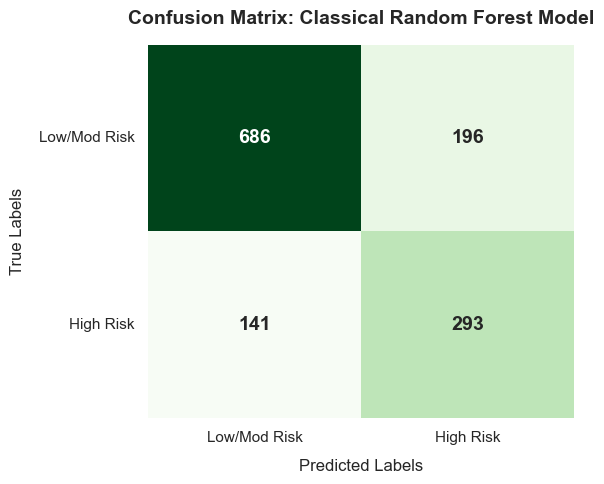

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time

# ---------------------------------------------------------
# 1. Load and Preprocess Data (Matching your XGBoost pattern)
# ---------------------------------------------------------
print("Preparing dataset for Random Forest...")
df = pd.read_csv('dataset_2020-2025.csv')

# Dynamic environmental drivers ONLY
features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 2. Initialize and Train Random Forest Classifier
# ---------------------------------------------------------
print("\nTraining Random Forest Classifier...")
start_time = time.perf_counter()

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    class_weight='balanced', # Handles class imbalance naturally
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
trained_rf_model = rf_model
rf_scaler = scaler
rf_X_test_raw = X_test.copy()
rf_X_test_scaled = X_test_scaled.copy()
rf_y_test = y_test.copy()
training_time = time.perf_counter() - start_time
print(f"Training complete in {training_time:.4f} seconds!")

# ---------------------------------------------------------
# 3. Predictions and Evaluation
# ---------------------------------------------------------
print("\nRunning predictions...")
y_pred = rf_model.predict(X_test_scaled)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n================ CLASSICAL RANDOM FOREST ================")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("=========================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 4. Generate and Plot Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Classical Random Forest Model', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12, labelpad=10)
plt.ylabel('True Labels', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()

plt.savefig('rf_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'rf_confusion_matrix.png'!")
plt.show()

# Support Vector Machine (SVM) with an RBF kernel

Preparing dataset for Support Vector Machine...

Training SVM Classifier (RBF Kernel)...
Training complete in 0.6084 seconds!

Running predictions...

================ CLASSICAL SVM (RBF KERNEL) ================
Training Time: 0.6084 seconds
Accuracy:      0.7698
Precision:     0.6329
Recall:        0.7189
F1-Score:      0.6731

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.85      0.79      0.82       882
   High Risk       0.63      0.72      0.67       434

    accuracy                           0.77      1316
   macro avg       0.74      0.76      0.75      1316
weighted avg       0.78      0.77      0.77      1316


Confusion matrix visualization saved successfully as 'svm_confusion_matrix.png'!


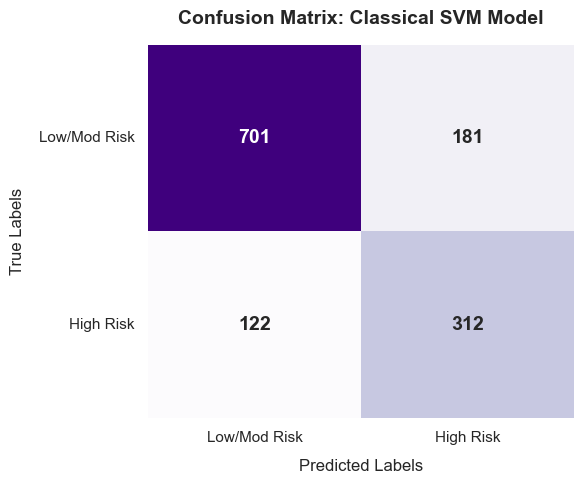

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time

# ---------------------------------------------------------
# 1. Load and Preprocess Data (Matching previous baselines)
# ---------------------------------------------------------
print("Preparing dataset for Support Vector Machine...")
df = pd.read_csv('dataset_2020-2025.csv')

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 2. Initialize and Train Support Vector Classifier
# ---------------------------------------------------------
print("\nTraining SVM Classifier (RBF Kernel)...")
start_time = time.perf_counter()

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced', # Handles class imbalance naturally
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
trained_svm_model = svm_model
svm_scaler = scaler
svm_X_test_scaled = X_test_scaled.copy()
svm_y_test = y_test.copy()
training_time = time.perf_counter() - start_time
print(f"Training complete in {training_time:.4f} seconds!")

# ---------------------------------------------------------
# 3. Predictions and Evaluation
# ---------------------------------------------------------
print("\nRunning predictions...")
y_pred = svm_model.predict(X_test_scaled)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n================ CLASSICAL SVM (RBF KERNEL) ================")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("=============================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 4. Generate and Plot Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Purples', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Classical SVM Model', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12, labelpad=10)
plt.ylabel('True Labels', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()

plt.savefig('svm_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'svm_confusion_matrix.png'!")
plt.show()

# Classical - XGBoost Model

Preparing dataset...
Original Dataset Profiles:
 - Low/Moderate Risk samples in training: 3523
 - High Risk samples in training: 1737
 - Calculated scale_pos_weight: 2.0282

Training XGBoost Classifier...
Training complete in 0.0947 seconds!

Running predictions...

================ CLASSICAL XGBOOST (NO SMOTE) ================
Training Time: 0.0947 seconds
Accuracy:  0.7584
Precision: 0.6184
Recall:    0.6982
F1-Score:  0.6558

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.84      0.79      0.81       882
   High Risk       0.62      0.70      0.66       434

    accuracy                           0.76      1316
   macro avg       0.73      0.74      0.73      1316
weighted avg       0.77      0.76      0.76      1316


Confusion matrix visualization saved successfully as 'xgb_confusion_matrix.png'!


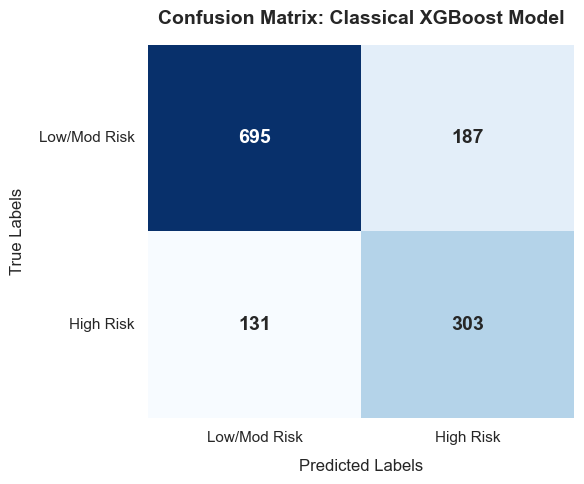

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb

# ---------------------------------------------------------
# 1. Load and Preprocess Data (No SMOTE)
# ---------------------------------------------------------
print("Preparing dataset...")
df = pd.read_csv('dataset_2020-2025.csv')

# Dynamic environmental drivers ONLY (Data leakage removed)
features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate the exact class imbalance ratio directly from your dataset
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
imbalance_ratio = num_low_mod / num_high

print(f"Original Dataset Profiles:")
print(f" - Low/Moderate Risk samples in training: {num_low_mod}")
print(f" - High Risk samples in training: {num_high}")
print(f" - Calculated scale_pos_weight: {imbalance_ratio:.4f}")

# ---------------------------------------------------------
# 2. Initialize and Train XGBoost Classifier
# ---------------------------------------------------------
print("\nTraining XGBoost Classifier...")
start_time = time.perf_counter()

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,  # <-- Handles imbalance directly on your raw data
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
trained_xgb_model = xgb_model
xgb_scaler = scaler
xgb_X_test_scaled = X_test_scaled.copy()
xgb_y_test = y_test.copy()
training_time = time.perf_counter() - start_time
print(f"Training complete in {training_time:.4f} seconds!")

# ---------------------------------------------------------
# 3. Predictions and Evaluation
# ---------------------------------------------------------
print("\nRunning predictions...")
y_pred = xgb_model.predict(X_test_scaled)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n================ CLASSICAL XGBOOST (NO SMOTE) ================")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("==============================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 5. Generate and Plot Confusion Matrix
# ---------------------------------------------------------
# Compute the 2x2 confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Set up the plotting environment
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

# Plot using a seaborn heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

# Formatting labels and titles
plt.title('Confusion Matrix: Classical XGBoost Model', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12, labelpad=10)
plt.ylabel('True Labels', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()

# Save the matrix image for your report/presentation
plt.savefig('xgb_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'xgb_confusion_matrix.png'!")

# Display the plot
plt.show()

# Quantum Model: Data Re-uploading Classifier

Preparing dataset for Data Re-uploading Quantum Classifier...
Safety Multiplier for High Risk Class: 2.0282

Starting Data Re-uploading Quantum Training...
Epoch 01 | Safety Loss: 1.3339 | Est. Train Acc: 0.63
Epoch 02 | Safety Loss: 1.0962 | Est. Train Acc: 0.65
Epoch 03 | Safety Loss: 1.1170 | Est. Train Acc: 0.69
Epoch 04 | Safety Loss: 1.1051 | Est. Train Acc: 0.73
Epoch 05 | Safety Loss: 0.7676 | Est. Train Acc: 0.69
Epoch 06 | Safety Loss: 0.8663 | Est. Train Acc: 0.67
Epoch 07 | Safety Loss: 1.4547 | Est. Train Acc: 0.67
Epoch 08 | Safety Loss: 0.9181 | Est. Train Acc: 0.67
Quantum Training complete in 565.9380 seconds!

Evaluating Data Re-uploading Model on Test Dataset...

========= DATA RE-UPLOADING QUANTUM CLASSIFIER ==========
Training Time: 565.9380 seconds
Accuracy:      0.6953
Precision:     0.5301
Recall:        0.6705
F1-Score:      0.5921

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.81      0.71      0.76

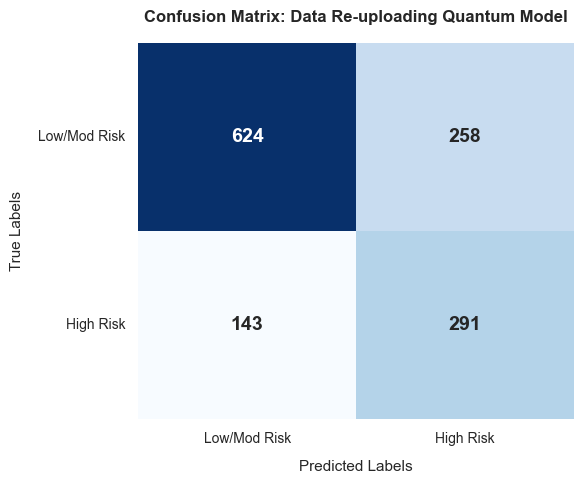

In [4]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ---------------------------------------------------------
# 1. Load and Preprocess Data (Matching previous pipeline)
# ---------------------------------------------------------
print("Preparing dataset for Data Re-uploading Quantum Classifier...")
df = pd.read_csv('dataset_2020-2025.csv')

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality Reduction (4 Qubits via PCA)
num_qubits = 4
pca = PCA(n_components=num_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Scale strictly to [-pi, pi] for rotational encoding
q_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_final = pnp.array(q_scaler.fit_transform(X_train_pca), requires_grad=False)
X_test_final = pnp.array(q_scaler.transform(X_test_pca), requires_grad=False)
data_reuploading_4q_scaler = scaler
data_reuploading_4q_pca = pca
data_reuploading_4q_angle_scaler = q_scaler
data_reuploading_4q_X_test_scaled = X_test_scaled.copy()
data_reuploading_4q_y_test = y_test.copy()

# PennyLane targets: -1 for Low/Mod, 1 for High Risk
y_train_final = pnp.array(np.where(y_train == 0, -1, 1), requires_grad=False)
y_test_final = np.where(y_test == 0, -1, 1)

# Imbalance safety multiplier
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
high_risk_weight = num_low_mod / num_high
print(f"Safety Multiplier for High Risk Class: {high_risk_weight:.4f}")

# ---------------------------------------------------------
# 2. Data Re-uploading Quantum Architecture Definition
# ---------------------------------------------------------
dev = qml.device("lightning.qubit", wires=num_qubits)
num_layers = 3  # Number of re-uploading layers

@qml.qnode(dev)
def data_reuploading_classifier(weights_data_reuploading_4q, x):
    """
    Data Re-uploading Circuit: Interleaves feature embedding 
    with trainable variational rotations and entangling gates across layers.
    """
    for l in range(num_layers):
        # 1. Re-upload data features at each layer using Rot gates
        for i in range(num_qubits):
            qml.Rot(x[i], x[i], x[i], wires=i)
        
        # 2. Trainable Variational Rotations
        for i in range(num_qubits):
            qml.Rot(weights_data_reuploading_4q[l, i, 0], weights_data_reuploading_4q[l, i, 1], weights_data_reuploading_4q[l, i, 2], wires=i)
            
        # 3. Entangling ring (CNOT gates)
        for i in range(num_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[num_qubits - 1, 0])
        
    return qml.expval(qml.PauliZ(0))

# Initialize weights_data_reuploading_4q (num_layers, num_qubits, 3 rotation parameters per qubit)
weight_shape = (num_layers, num_qubits, 3)
weights_data_reuploading_4q = pnp.random.uniform(low=-np.pi, high=np.pi, size=weight_shape, requires_grad=True)

# ---------------------------------------------------------
# 3. Cost-Sensitive Optimization & Training
# ---------------------------------------------------------
def safety_loss_func(weights_data_reuploading_4q, X_batch, y_batch):
    loss = 0.0
    for x, y_true in zip(X_batch, y_batch):
        pred = data_reuploading_classifier(weights_data_reuploading_4q, x)
        base_error = (pred - y_true) ** 2
        weight_factor = pnp.where(y_true == 1, high_risk_weight, 1.0)
        loss += weight_factor * base_error
    return loss / len(X_batch)

opt = qml.AdamOptimizer(stepsize=0.01)
batch_size = 64
epochs = 8

print("\nStarting Data Re-uploading Quantum Training...")
start_time = time.perf_counter()

for epoch in range(epochs):
    permutation = np.random.permutation(len(X_train_final))
    X_shuffled = X_train_final[permutation]
    y_shuffled = y_train_final[permutation]
    
    for i in range(0, len(X_train_final), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        weights_data_reuploading_4q, cost = opt.step_and_cost(lambda w: safety_loss_func(w, X_batch, y_batch), weights_data_reuploading_4q)
        
    train_preds = [np.sign(data_reuploading_classifier(weights_data_reuploading_4q, x)) for x in X_train_final[:200]]
    train_acc = accuracy_score(y_train_final[:200], train_preds)
    print(f"Epoch {epoch+1:02d} | Safety Loss: {cost:.4f} | Est. Train Acc: {train_acc:.2f}")

trained_weights_data_reuploading_4q = weights_data_reuploading_4q.copy()
training_time = time.perf_counter() - start_time
print(f"Quantum Training complete in {training_time:.4f} seconds!")

# ---------------------------------------------------------
# 4. Final Evaluation & Metrics
# ---------------------------------------------------------
print("\nEvaluating Data Re-uploading Model on Test Dataset...")
raw_preds = [data_reuploading_classifier(weights_data_reuploading_4q, x) for x in X_test_final]
y_pred = np.sign(raw_preds)

accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test_final, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test_final, y_pred, pos_label=1, zero_division=0)

print("\n========= DATA RE-UPLOADING QUANTUM CLASSIFIER ==========")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("=========================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test_final, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 5. Confusion Matrix Visualization
# ---------------------------------------------------------
cm_quantum = confusion_matrix(y_test_final, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm_quantum, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Data Re-uploading Quantum Model', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()

plt.savefig('data_reuploading_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'data_reuploading_confusion_matrix.png'!")
plt.show()

# Standard VQC Model

Preparing dataset for Standard VQC Classifier...

Starting Standard VQC Quantum Training...
Epoch 01 | Safety Loss: 1.6783 | Est. Train Acc: 0.69
Epoch 02 | Safety Loss: 1.2596 | Est. Train Acc: 0.76
Epoch 03 | Safety Loss: 0.9079 | Est. Train Acc: 0.74
Epoch 04 | Safety Loss: 0.7609 | Est. Train Acc: 0.71
Epoch 05 | Safety Loss: 1.2788 | Est. Train Acc: 0.73
Epoch 06 | Safety Loss: 0.9058 | Est. Train Acc: 0.74
Epoch 07 | Safety Loss: 0.6065 | Est. Train Acc: 0.74
Epoch 08 | Safety Loss: 1.2958 | Est. Train Acc: 0.71
VQC Training complete in 1103.1403 seconds!

Evaluating Standard VQC Model on Test Dataset...

============== STANDARD VQC CLASSIFIER ===============
Training Time: 1103.1403 seconds
Accuracy:      0.7181
Precision:     0.5731
Recall:        0.5691
F1-Score:      0.5711

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.79      0.79      0.79       882
   High Risk       0.57      0.57      0.57       434

    accu

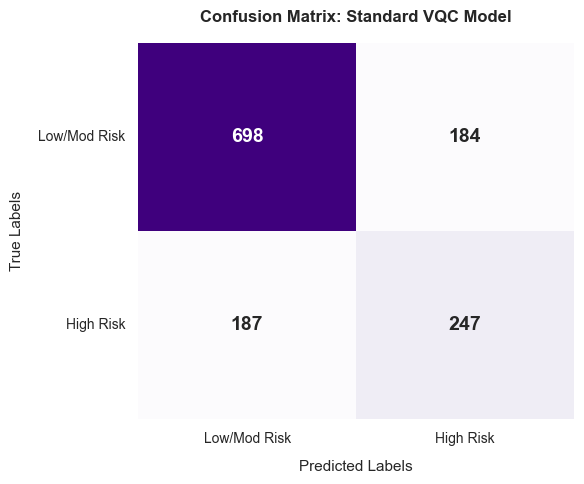

In [5]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ---------------------------------------------------------
# 1. Load and Preprocess Data
# ---------------------------------------------------------
print("Preparing dataset for Standard VQC Classifier...")
df = pd.read_csv('dataset_2020-2025.csv')

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_qubits = 4
pca = PCA(n_components=num_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

q_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_final = pnp.array(q_scaler.fit_transform(X_train_pca), requires_grad=False)
X_test_final = pnp.array(q_scaler.transform(X_test_pca), requires_grad=False)
standard_vqc_scaler = scaler
standard_vqc_pca = pca
standard_vqc_angle_scaler = q_scaler
standard_vqc_X_test_scaled = X_test_scaled.copy()
standard_vqc_y_test = y_test.copy()

y_train_final = pnp.array(np.where(y_train == 0, -1, 1), requires_grad=False)
y_test_final = np.where(y_test == 0, -1, 1)

num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
high_risk_weight = num_low_mod / num_high

# ---------------------------------------------------------
# 2. Standard VQC Architecture Definition (Single Embedding)
# ---------------------------------------------------------
dev = qml.device("lightning.qubit", wires=num_qubits)
num_layers = 4

@qml.qnode(dev)
def vqc_classifier(standard_vqc_weights, x):
    # 1. Angle Embedding ONCE at the start
    qml.AngleEmbedding(x, wires=range(num_qubits), rotation='X')
    # 2. Strongly Entangling Layers (Trainable standard_vqc_weights only)
    qml.StronglyEntanglingLayers(standard_vqc_weights, wires=range(num_qubits))
    return qml.expval(qml.PauliZ(0))

weight_shape = (num_layers, num_qubits, 3)
standard_vqc_weights = pnp.random.uniform(low=-np.pi, high=np.pi, size=weight_shape, requires_grad=True)

# ---------------------------------------------------------
# 3. Cost-Sensitive Optimization & Training
# ---------------------------------------------------------
def safety_loss_func(standard_vqc_weights, X_batch, y_batch):
    loss = 0.0
    for x, y_true in zip(X_batch, y_batch):
        pred = vqc_classifier(standard_vqc_weights, x)
        base_error = (pred - y_true) ** 2
        weight_factor = pnp.where(y_true == 1, high_risk_weight, 1.0)
        loss += weight_factor * base_error
    return loss / len(X_batch)

opt = qml.AdamOptimizer(stepsize=0.01)
batch_size = 64
epochs = 8

print("\nStarting Standard VQC Quantum Training...")
start_time = time.perf_counter()

for epoch in range(epochs):
    permutation = np.random.permutation(len(X_train_final))
    X_shuffled = X_train_final[permutation]
    y_shuffled = y_train_final[permutation]
    
    for i in range(0, len(X_train_final), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        standard_vqc_weights, cost = opt.step_and_cost(lambda w: safety_loss_func(w, X_batch, y_batch), standard_vqc_weights)
        
    train_preds = [np.sign(vqc_classifier(standard_vqc_weights, x)) for x in X_train_final[:200]]
    train_acc = accuracy_score(y_train_final[:200], train_preds)
    print(f"Epoch {epoch+1:02d} | Safety Loss: {cost:.4f} | Est. Train Acc: {train_acc:.2f}")

trained_weights_standard_vqc = standard_vqc_weights.copy()
training_time = time.perf_counter() - start_time
print(f"VQC Training complete in {training_time:.4f} seconds!")

# ---------------------------------------------------------
# 4. Final Evaluation & Metrics
# ---------------------------------------------------------
print("\nEvaluating Standard VQC Model on Test Dataset...")
raw_preds = [vqc_classifier(standard_vqc_weights, x) for x in X_test_final]
y_pred = np.sign(raw_preds)

accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test_final, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test_final, y_pred, pos_label=1, zero_division=0)

print("\n============== STANDARD VQC CLASSIFIER ===============")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("========================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test_final, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 5. Confusion Matrix Visualization
# ---------------------------------------------------------
cm_quantum = confusion_matrix(y_test_final, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm_quantum, 
    annot=True, 
    fmt='d', 
    cmap='Purples', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Standard VQC Model', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()

plt.savefig('vqc_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'vqc_confusion_matrix.png'!")
plt.show()


# 6-Qubit Data Re-uploading Model

Preparing dataset for 6-Qubit Data Re-uploading Classifier...
Safety Multiplier for High Risk Class: 2.0282

Starting 6-Qubit Data Re-uploading Quantum Training...
Epoch 01 | Safety Loss: 1.4018 | Est. Train Acc: 0.65
Epoch 02 | Safety Loss: 0.9343 | Est. Train Acc: 0.65
Epoch 03 | Safety Loss: 0.9294 | Est. Train Acc: 0.67
Epoch 04 | Safety Loss: 1.1544 | Est. Train Acc: 0.70
Epoch 05 | Safety Loss: 1.0207 | Est. Train Acc: 0.72
Epoch 06 | Safety Loss: 1.3018 | Est. Train Acc: 0.74

6-Qubit Training complete in 1068.6162 seconds!

Evaluating 6-Qubit Model on Test Dataset...

========= 6-QUBIT DATA RE-UPLOADING CLASSIFIER =========
Training Time: 1068.6162 seconds
Accuracy:      0.6900
Precision:     0.5241
Recall:        0.6521
F1-Score:      0.5811

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.81      0.71      0.75       882
   High Risk       0.52      0.65      0.58       434

    accuracy                           0.6

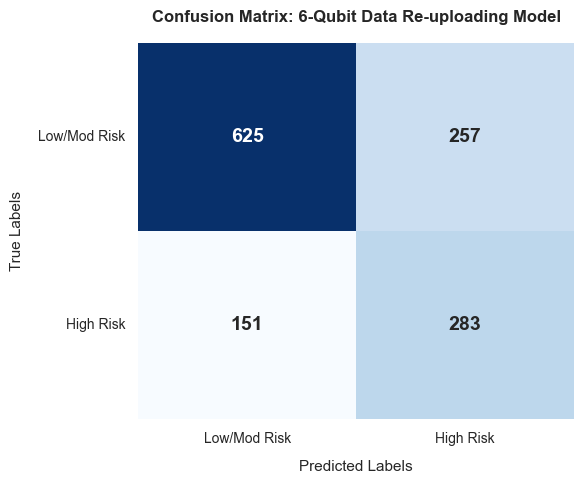

In [6]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Load and preprocess data
print("Preparing dataset for 6-Qubit Data Re-uploading Classifier...")
df = pd.read_csv('dataset_2020-2025.csv')
features_to_use = [
    'wave_height', 'wave_period', 'wave_direction',
    'precipitation', 'wind_speed', 'tidal_height_m'
]

X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA to 6 qubits
num_qubits = 6
pca = PCA(n_components=num_qubits)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Scale values to [-pi, pi] for quantum encoding
q_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

X_train_final = pnp.array(q_scaler.fit_transform(X_train_pca), requires_grad=False)
X_test_final = pnp.array(q_scaler.transform(X_test_pca), requires_grad=False)
data_reuploading_6q_scaler = scaler
data_reuploading_6q_pca = pca
data_reuploading_6q_angle_scaler = q_scaler
data_reuploading_6q_X_test_scaled = X_test_scaled.copy()
data_reuploading_6q_y_test = y_test.copy()

# PennyLane labels: Low/Moderate = -1, High = +1
y_train_final = pnp.array(np.where(y_train == 0, -1, 1), requires_grad=False)
y_test_final = np.where(y_test == 0, -1, 1)

# Calculate high-risk class weight
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
high_risk_weight = num_low_mod / num_high

print(f"Safety Multiplier for High Risk Class: {high_risk_weight:.4f}")

# 2. 6-Qubit Data Re-uploading Architecture
dev = qml.device("lightning.qubit", wires=num_qubits)
num_layers = 3

@qml.qnode(dev)
def data_reuploading_6q(weights_data_reuploading_6q, x):
    for l in range(num_layers):
        # Data encoding
        for i in range(num_qubits):
            qml.Rot(x[i], x[i], x[i], wires=i)

        # Trainable rotations
        for i in range(num_qubits):
            qml.Rot(weights_data_reuploading_6q[l, i, 0], weights_data_reuploading_6q[l, i, 1], weights_data_reuploading_6q[l, i, 2], wires=i)

        # Ring entanglement
        for i in range(num_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[num_qubits - 1, 0])

    return qml.expval(qml.PauliZ(0))

# Initialize trainable weights_data_reuploading_6q
weight_shape = (num_layers, num_qubits, 3)
weights_data_reuploading_6q = pnp.random.uniform(low=-np.pi, high=np.pi, size=weight_shape, requires_grad=True)

# 3. Cost-sensitive loss function
def safety_loss_func(weights_data_reuploading_6q, X_batch, y_batch):
    loss = 0.0
    for x, y_true in zip(X_batch, y_batch):
        pred = data_reuploading_6q(weights_data_reuploading_6q, x)
        base_error = (pred - y_true) ** 2

        weight_factor = pnp.where(y_true == 1, high_risk_weight, 1.0)
        loss += weight_factor * base_error

    return loss / len(X_batch)

# 4. Training
opt = qml.AdamOptimizer(stepsize=0.01)
batch_size = 64
epochs = 6

print("\nStarting 6-Qubit Data Re-uploading Quantum Training...")
start_time = time.perf_counter()

for epoch in range(epochs):
    permutation = np.random.permutation(len(X_train_final))
    X_shuffled = X_train_final[permutation]
    y_shuffled = y_train_final[permutation]

    for i in range(0, len(X_train_final), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        weights_data_reuploading_6q, cost = opt.step_and_cost(lambda w: safety_loss_func(w, X_batch, y_batch), weights_data_reuploading_6q)

    train_preds = [np.sign(data_reuploading_6q(weights_data_reuploading_6q, x)) for x in X_train_final[:200]]
    train_acc = accuracy_score(y_train_final[:200], train_preds)

    print(f"Epoch {epoch + 1:02d} | "f"Safety Loss: {cost:.4f} | "f"Est. Train Acc: {train_acc:.2f}")

trained_weights_data_reuploading_6q = weights_data_reuploading_6q.copy()
training_time = time.perf_counter() - start_time
print(f"\n6-Qubit Training complete in " f"{training_time:.4f} seconds!")

# 5. Final evaluation
print("\nEvaluating 6-Qubit Model on Test Dataset...")
raw_preds = [data_reuploading_6q(weights_data_reuploading_6q, x) for x in X_test_final]

y_pred = np.sign(raw_preds)
# Calculate metrics
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test_final, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test_final, y_pred, pos_label=1, zero_division=0)

print("\n========= 6-QUBIT DATA RE-UPLOADING CLASSIFIER =========")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("========================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test_final, y_pred, labels=[-1, 1], target_names=['Low/Mod Risk', 'High Risk'], zero_division=0))

# 6. Confusion matrix
cm_quantum = confusion_matrix(y_test_final, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")
sns.heatmap(cm_quantum, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Low/Mod Risk', 'High Risk'], 
            yticklabels=['Low/Mod Risk', 'High Risk'], annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix: 6-Qubit Data Re-uploading Model', fontsize=12, pad=15, weight='bold')

plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)

plt.tight_layout()
plt.savefig('data_reuploading_6q_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'data_reuploading_6q_confusion_matrix.png'!")
plt.show()

# Old Quantum Model

Preparing dataset for Cost-Sensitive PennyLane...
Safety Multiplier for High Risk Class: 2.0282

Starting Quantum Training with Safety-Weighted Cost Function...
Epoch 01 | Safety Loss: 1.6665 | Est. Train Acc: 0.74
Epoch 02 | Safety Loss: 0.9302 | Est. Train Acc: 0.74
Epoch 03 | Safety Loss: 1.1920 | Est. Train Acc: 0.74
Epoch 04 | Safety Loss: 0.7534 | Est. Train Acc: 0.71
Epoch 05 | Safety Loss: 0.6623 | Est. Train Acc: 0.71
Epoch 06 | Safety Loss: 0.9784 | Est. Train Acc: 0.70
Epoch 07 | Safety Loss: 0.9169 | Est. Train Acc: 0.70
Epoch 08 | Safety Loss: 0.8993 | Est. Train Acc: 0.72
Epoch 09 | Safety Loss: 1.0210 | Est. Train Acc: 0.71
Epoch 10 | Safety Loss: 1.4724 | Est. Train Acc: 0.72

Training complete in 1254.4029 seconds!

Evaluating on Test Dataset...

================ SAFETY-OPTIMIZED PENNYLANE EVALUATION ================

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.79      0.76      0.78       882
   High Risk

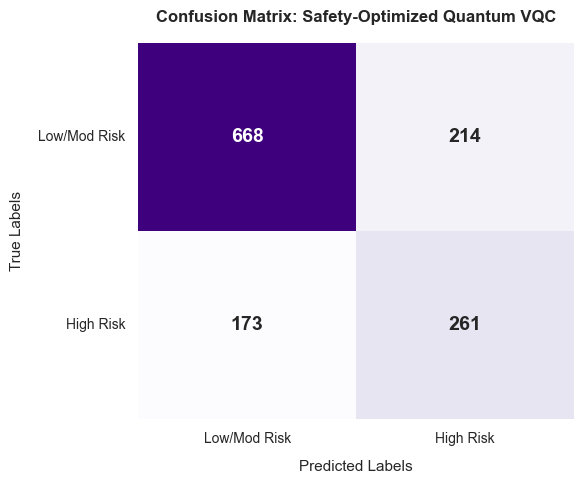

In [7]:
import pandas as pd
import numpy as np
import time
import pennylane as qml
from pennylane import numpy as pnp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. LOAD AND PREPROCESS DATA
# =========================================================

print("Preparing dataset for Cost-Sensitive PennyLane...")
df = pd.read_csv('dataset_2020-2025.csv')
features_to_use = [
    'wave_height', 'wave_period', 'wave_direction',
    'precipitation', 'wind_speed', 'tidal_height_m'
]

X = df[features_to_use].values
# High Risk = 1, Low/Moderate Risk = 0
y = df['erosion_risk'].apply(    lambda x: 1 if x == 'High' else 0).values

# =========================================================
# 2. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =========================================================
# 3. NORMALIZE FEATURES
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 4. PCA DIMENSIONALITY REDUCTION
# =========================================================
num_qubits = 4
pca = PCA(n_components=num_qubits)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# =========================================================
# 5. SCALE FEATURES TO [-π, π]
# =========================================================
q_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_final = pnp.array(q_scaler.fit_transform(X_train_pca), requires_grad=False)
X_test_final = pnp.array(q_scaler.transform(X_test_pca),requires_grad=False)
old_quantum_scaler = scaler
old_quantum_pca = pca
old_quantum_angle_scaler = q_scaler
old_quantum_X_test_scaled = X_test_scaled.copy()
old_quantum_y_test = y_test.copy()

# =========================================================
# 6. CONVERT TARGETS FOR PENNYLANE
# =========================================================
# Low/Moderate Risk = -1
# High Risk = +1
y_train_final = pnp.array(np.where(y_train == 0, -1, 1), requires_grad=False)
y_test_final = np.where(y_test == 0, -1, 1)

# =========================================================
# 7. CALCULATE HIGH-RISK CLASS WEIGHT
# =========================================================
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
high_risk_weight = num_low_mod / num_high
print(f"Safety Multiplier for High Risk Class: "f"{high_risk_weight:.4f}")

# =========================================================
# 8. QUANTUM ARCHITECTURE
# =========================================================
dev = qml.device("lightning.qubit", wires=num_qubits)

@qml.qnode(dev)
def quantum_classifier(old_quantum_weights, x):
    # Encode classical data into quantum circuit
    qml.AngleEmbedding(x, wires=range(num_qubits), rotation='X')
    # Variational quantum layers
    qml.StronglyEntanglingLayers(old_quantum_weights, wires=range(num_qubits))
    # Measurement
    return qml.expval(qml.PauliZ(0))

# =========================================================
# 9. INITIALIZE QUANTUM MODEL WEIGHTS
# =========================================================
num_layers = 4
weight_shape = (num_layers, num_qubits, 3)
old_quantum_weights = pnp.random.uniform(low=-np.pi, high=np.pi, size=weight_shape, requires_grad=True)

# =========================================================
# 10. COST-SENSITIVE LOSS FUNCTION
# =========================================================
def safety_loss_func(old_quantum_weights, X_batch, y_batch):
    loss = 0.0
    for x, y_true in zip(X_batch, y_batch):
        # Quantum prediction
        pred = quantum_classifier(old_quantum_weights, x)
        # Squared error
        base_error = (pred - y_true) ** 2
        # Give higher penalty to High Risk samples
        weight_factor = pnp.where(y_true == 1, high_risk_weight, 1.0)
        loss += (weight_factor * base_error)

    return loss / len(X_batch)

# =========================================================
# 11. OPTIMIZATION PARAMETERS
# =========================================================
opt = qml.AdamOptimizer(stepsize=0.01)
batch_size = 64
epochs = 10

# =========================================================
# 12. TRAINING
# =========================================================
print("\nStarting Quantum Training with Safety-Weighted Cost Function...")
start_time = time.perf_counter()

for epoch in range(epochs):
    # Shuffle training data
    permutation = np.random.permutation(len(X_train_final))
    X_shuffled = X_train_final[permutation]
    y_shuffled = y_train_final[permutation]

    # Mini-batch training
    for i in range(0, len(X_train_final), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        old_quantum_weights, cost = opt.step_and_cost(lambda w: safety_loss_func(w, X_batch, y_batch), old_quantum_weights)

    # Estimate training accuracy
    train_preds = [np.sign(quantum_classifier(old_quantum_weights, x))for x in X_train_final[:200]]
    train_acc = accuracy_score(y_train_final[:200], train_preds)
    print(f"Epoch {epoch + 1:02d} | " f"Safety Loss: {cost:.4f} | " f"Est. Train Acc: {train_acc:.2f}")

trained_weights_old_quantum = old_quantum_weights.copy()
training_time = (time.perf_counter() - start_time)
print(f"\nTraining complete in " f"{training_time:.4f} seconds!")

# =========================================================
# 13. FINAL EVALUATION
# =========================================================
print("\nEvaluating on Test Dataset...")
# Generate quantum predictions
raw_preds = [quantum_classifier(old_quantum_weights, x) for x in X_test_final]

# Convert quantum outputs to -1 / +1
y_pred = np.sign(raw_preds)

# =========================================================
# 14. CALCULATE EVALUATION METRICS
# =========================================================
# Overall accuracy
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred, pos_label=1)
recall = recall_score(y_test_final, y_pred, pos_label=1)
f1 = f1_score(y_test_final, y_pred, pos_label=1)

# =========================================================
# 15. PRINT FINAL RESULTS
# =========================================================
print("\n================ SAFETY-OPTIMIZED PENNYLANE EVALUATION ================")
print("\nDetailed Classification Report:")
print(classification_report(y_test_final, y_pred, labels=[-1, 1], target_names=['Low/Mod Risk', 'High Risk']))
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("========================================================")

# =========================================================
# 16. CONFUSION MATRIX
# =========================================================
cm_quantum = confusion_matrix(
    y_test_final,
    y_pred,
    labels=[-1, 1]
)
# =========================================================
# 17. PLOT CONFUSION MATRIX
# =========================================================
plt.figure(figsize=(6, 5))
sns.set_theme(style="white")
sns.heatmap(cm_quantum, annot=True, fmt='d', cmap='Purples', cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'],
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

# Formatting
plt.title('Confusion Matrix: Safety-Optimized Quantum VQC', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()

# =========================================================
# 18. SAVE CONFUSION MATRIX
# =========================================================
plt.savefig('quantum_confusion_matrix.png', dpi=300)            
print("\nConfusion matrix visualization saved successfully as 'quantum_confusion_matrix.png'!")
plt.show()

# Hybrid Model Code: PyTorch + PennyLane Hybrid Neural Network

In [8]:
!pip install torch


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Preparing dataset for Hybrid Quantum-Classical Neural Network...

Training Hybrid Quantum-Classical Neural Network...
Epoch 01/10 | Loss: 0.5318
Epoch 02/10 | Loss: 0.4072
Epoch 03/10 | Loss: 0.3873
Epoch 04/10 | Loss: 0.3861
Epoch 05/10 | Loss: 0.3896
Epoch 06/10 | Loss: 0.3777
Epoch 07/10 | Loss: 0.3765
Epoch 08/10 | Loss: 0.3752
Epoch 09/10 | Loss: 0.3740
Epoch 10/10 | Loss: 0.3708
Hybrid Training complete in 1387.0557 seconds!

Evaluating Hybrid Model on Test Dataset...

========= HYBRID QUANTUM-CLASSICAL NEURAL NETWORK =========
Training Time: 1387.0557 seconds
Accuracy:      0.8100
Precision:     0.8333
Recall:        0.5300
F1-Score:      0.6479

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.80      0.95      0.87       882
   High Risk       0.83      0.53      0.65       434

    accuracy                           0.81      1316
   macro avg       0.82      0.74      0.76      1316
weighted avg       0.81      0.81 

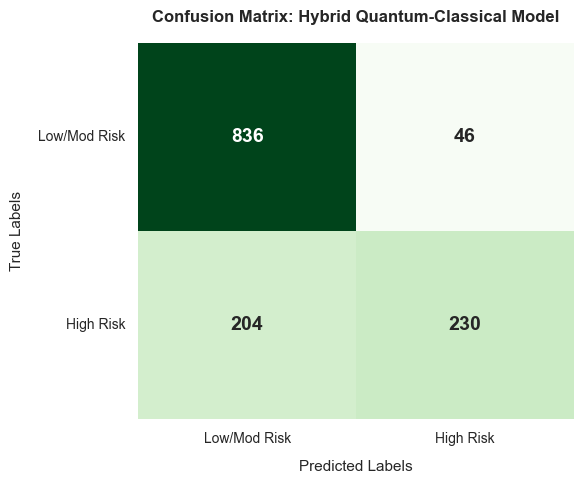

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# ---------------------------------------------------------
# 1. Load and Preprocess Data
# ---------------------------------------------------------
print("Preparing dataset for Hybrid Quantum-Classical Neural Network...")
df = pd.read_csv('dataset_2020-2025.csv')

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]
X = df[features_to_use].values
y = df['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
hybrid_scaler = scaler
hybrid_X_test_scaled = X_test_scaled.copy()
hybrid_y_test = y_test.copy()
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ---------------------------------------------------------
# 2. Define PennyLane Quantum Device & Node (4 Qubits)
# ---------------------------------------------------------
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, hybrid_quantum_weights):
    # Scale inputs to [-pi, pi] for angle embedding
    scaled_inputs = inputs * np.pi
    for i in range(n_qubits):
        qml.RY(scaled_inputs[i], wires=i)
        
    # Variational layers with hybrid_quantum_weights shape (n_layers, n_qubits, 3)
    qml.StronglyEntanglingLayers(hybrid_quantum_weights, wires=range(n_qubits))
    
    # Return Pauli-Z expectation value for each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# ---------------------------------------------------------
# 3. Build Hybrid PyTorch Model
# ---------------------------------------------------------
class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()
        # Classical pre-processing layers
        self.fc1 = nn.Linear(len(features_to_use), 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, n_qubits) # Maps hidden state to match qubit count
        
        # Quantum hybrid_quantum_weights parameter
        weight_shapes = {"hybrid_quantum_weights": (2, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        
        # Classical post-processing classification head
        self.fc3 = nn.Linear(n_qubits, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        # Pass through quantum layer (returns tensor of size [batch_size, n_qubits])
        quantum_outputs = []
        for sample in x:
            q_out = self.qlayer(sample)
            quantum_outputs.append(q_out)
        
        x = torch.stack(quantum_outputs)
        x = self.fc3(x)
        return self.sigmoid(x)

model = HybridModel()

# Class imbalance weight handling
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
pos_weight = torch.tensor([num_low_mod / num_high], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Using standard BCE since output uses sigmoid, or use BCELoss directly:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ---------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------
print("\nTraining Hybrid Quantum-Classical Neural Network...")
start_time = time.perf_counter()
epochs = 10
batch_size = 64

model.train()
for epoch in range(epochs):
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0.0
    
    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_x = X_train_tensor[indices]
        batch_y = y_train_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_size
        
    total_loss = epoch_loss / X_train_tensor.size(0)
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {total_loss:.4f}")

training_time = time.perf_counter() - start_time
print(f"Hybrid Training complete in {training_time:.4f} seconds!")
trained_hybrid_model = model

# ---------------------------------------------------------
# 5. Evaluation and Metrics
# ---------------------------------------------------------
print("\nEvaluating Hybrid Model on Test Dataset...")
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    y_pred = (test_outputs >= 0.5).float().numpy().flatten()

y_true = y_test_tensor.numpy().flatten()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n========= HYBRID QUANTUM-CLASSICAL NEURAL NETWORK =========")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("===========================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 6. Confusion Matrix Visualization
# ---------------------------------------------------------
cm_hybrid = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm_hybrid, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Hybrid Quantum-Classical Model', fontsize=12, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=11, labelpad=10)
plt.ylabel('True Labels', fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()

plt.savefig('hybrid_confusion_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'hybrid_confusion_matrix.png'!")
plt.show()

The Hybrid Architecture Strategy
Classical Feature Extraction Body (PyTorch Neural Network): A deep neural network extracts robust non-linear features from your environmental drivers (wave_height, wave_period, wave_direction, precipitation, wind_speed, tidal_height_m).

Quantum Bottleneck / Activation Layer (PennyLane PQC): The output of the classical hidden layers is mapped into a parameterized quantum circuit. The quantum circuit acts as a high-dimensional, entangled non-linear kernel/activation layer.

Classical Classification Head: The expectation values extracted from the quantum circuit feed into a final linear classification layer to output high-accuracy risk probabilities.

Here is how the hybrid model works:

Classical Model: A PyTorch Feedforward Neural Network (Multi-Layer Perceptron / MLP) consisting of linear layers (fc1, fc2) with ReLU activation.

Quantum Model: A PennyLane Variational Quantum Circuit (VQC) utilizing Angle Embedding (qml.RY) and qml.StronglyEntanglingLayers wrapped as a differentiable PyTorch layer (TorchLayer).

Data Flow: Yes, the output of one feeds directly into the other in a sequential pipeline:

Classical Body: Ingests raw environmental features and maps them through hidden layers down to 4 dimensions (matching the qubit count).

Quantum Layer: Ingests those classical outputs as rotational angles, processing them through a multi-qubit entangled quantum circuit to act as a powerful non-linear feature transformation.

Classical Head: Takes the quantum expectation values and passes them through a final linear layer (fc3) with a Sigmoid activation to predict the final coastal erosion risk.

# Stress Test - F1 score

Starting noise stress testing on the preserved trained models...

Testing SNR = inf

Testing SNR = 10

Testing SNR = 5

Testing SNR = 1

Testing SNR = 0.1

Stress testing completed.

================ STRESS TEST RESULTS ================
           Random Forest  SVM (RBF)  XGBoost  4-Qubit Data Re-uploading  \
Clean             0.6349     0.6731   0.6558                     0.5921   
SNR = 10          0.5781     0.6032   0.5811                     0.5190   
SNR = 5           0.5263     0.5493   0.5176                     0.4917   
SNR = 1           0.4508     0.4965   0.4571                     0.4324   
SNR = 0.1         0.3917     0.4944   0.3922                     0.4261   

           Standard VQC  AE-VQC  6-Qubit Data Re-uploading  Hybrid QML  
Clean            0.5711  0.5743                     0.5811      0.6479  
SNR = 10         0.5455  0.5579                     0.4879      0.5247  
SNR = 5          0.5358  0.5378                     0.4391      0.4372  
SNR = 1          0.4

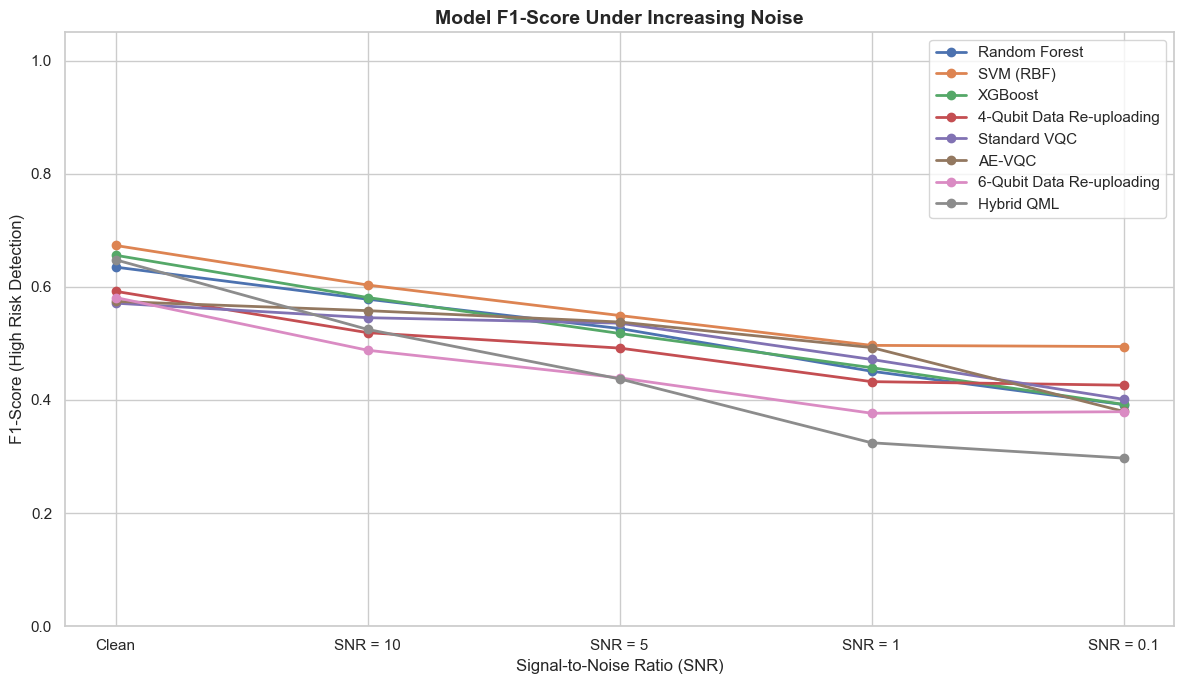

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns


required_artifacts = (
    "trained_rf_model",
    "rf_scaler",
    "rf_X_test_raw",
    "rf_y_test",
    "trained_svm_model",
    "svm_scaler",
    "trained_xgb_model",
    "xgb_scaler",
    "trained_weights_data_reuploading_4q",
    "data_reuploading_4q_scaler",
    "data_reuploading_4q_pca",
    "data_reuploading_4q_angle_scaler",
    "trained_weights_standard_vqc",
    "standard_vqc_scaler",
    "standard_vqc_pca",
    "standard_vqc_angle_scaler",
    "trained_weights_old_quantum",
    "old_quantum_scaler",
    "old_quantum_pca",
    "old_quantum_angle_scaler",
    "trained_weights_data_reuploading_6q",
    "data_reuploading_6q_scaler",
    "data_reuploading_6q_pca",
    "data_reuploading_6q_angle_scaler",
    "trained_hybrid_model",
    "hybrid_scaler",
)
missing_artifacts = [name for name in required_artifacts if name not in globals()]
if missing_artifacts:
    raise RuntimeError(
        "Run the model-training cells first; preserved artifacts are missing: "
        + ", ".join(missing_artifacts)
    )


y_test_stress = rf_y_test
X_test_raw_stress = rf_X_test_raw
X_test_scaled_clean = rf_scaler.transform(X_test_raw_stress)

label_sets = (
    svm_y_test,
    xgb_y_test,
    data_reuploading_4q_y_test,
    standard_vqc_y_test,
    old_quantum_y_test,
    data_reuploading_6q_y_test,
    hybrid_y_test,
)
if any(not np.array_equal(labels, y_test_stress) for labels in label_sets):
    raise ValueError("The trained models do not share the same held-out test split.")

scalers = (
    svm_scaler,
    xgb_scaler,
    data_reuploading_4q_scaler,
    standard_vqc_scaler,
    old_quantum_scaler,
    data_reuploading_6q_scaler,
    hybrid_scaler,
)
if any(
    not np.allclose(scaler.transform(X_test_raw_stress), X_test_scaled_clean)
    for scaler in scalers
):
    raise ValueError("The trained models use different scaled test inputs.")


def _quantum_predictions(qnode, trained_quantum_parameters, X_scaled, pca, angle_scaler):
    X_encoded = angle_scaler.transform(pca.transform(X_scaled))
    global num_qubits, num_layers
    previous_num_qubits, previous_num_layers = num_qubits, num_layers
    try:
        num_qubits = X_encoded.shape[1]
        num_layers = trained_quantum_parameters.shape[0]
        scores = [float(qnode(trained_quantum_parameters, sample)) for sample in X_encoded]
    finally:
        num_qubits, num_layers = previous_num_qubits, previous_num_layers
    return (np.sign(scores) == 1).astype(int)


def _hybrid_predictions(X_scaled):
    device = next(trained_hybrid_model.parameters()).device
    X_tensor = torch.as_tensor(X_scaled, dtype=torch.float32, device=device)
    trained_hybrid_model.eval()
    with torch.no_grad():
        outputs = trained_hybrid_model(X_tensor)
    return (outputs.detach().cpu().numpy().ravel() >= 0.5).astype(int)


snr_levels = [float("inf"), 10, 5, 1, 0.1]
x_labels = ["Clean", "SNR = 10", "SNR = 5", "SNR = 1", "SNR = 0.1"]

results = {
    "Random Forest": [],
    "SVM (RBF)": [],
    "XGBoost": [],
    "4-Qubit Data Re-uploading": [],
    "Standard VQC": [],
    "AE-VQC": [],
    "6-Qubit Data Re-uploading": [],
    "Hybrid QML": [],
}

print("Starting noise stress testing on the preserved trained models...")
for snr in snr_levels:
    print(f"\nTesting SNR = {snr}")

    if np.isinf(snr):
        noise = np.zeros_like(X_test_scaled_clean)
    else:
        signal_power = np.mean(X_test_scaled_clean ** 2, axis=0)
        noise_variance = signal_power / snr
        noise = np.random.normal(
            0,
            np.sqrt(noise_variance),
            X_test_scaled_clean.shape,
        )

    rf_inputs = rf_scaler.transform(X_test_raw_stress) + noise
    svm_inputs = svm_scaler.transform(X_test_raw_stress) + noise
    xgb_inputs = xgb_scaler.transform(X_test_raw_stress) + noise
    reupload4_inputs = data_reuploading_4q_scaler.transform(X_test_raw_stress) + noise
    vqc_inputs = standard_vqc_scaler.transform(X_test_raw_stress) + noise
    old_quantum_inputs = old_quantum_scaler.transform(X_test_raw_stress) + noise
    reupload6_inputs = data_reuploading_6q_scaler.transform(X_test_raw_stress) + noise
    hybrid_inputs = hybrid_scaler.transform(X_test_raw_stress) + noise

    predictions = {
        "Random Forest": trained_rf_model.predict(rf_inputs),
        "SVM (RBF)": trained_svm_model.predict(svm_inputs),
        "XGBoost": trained_xgb_model.predict(xgb_inputs),
        "4-Qubit Data Re-uploading": _quantum_predictions(
            data_reuploading_classifier,
            trained_weights_data_reuploading_4q,
            reupload4_inputs,
            data_reuploading_4q_pca,
            data_reuploading_4q_angle_scaler,
        ),
        "Standard VQC": _quantum_predictions(
            vqc_classifier,
            trained_weights_standard_vqc,
            vqc_inputs,
            standard_vqc_pca,
            standard_vqc_angle_scaler,
        ),
        "AE-VQC": _quantum_predictions(
            quantum_classifier,
            trained_weights_old_quantum,
            old_quantum_inputs,
            old_quantum_pca,
            old_quantum_angle_scaler,
        ),
        "6-Qubit Data Re-uploading": _quantum_predictions(
            data_reuploading_6q,
            trained_weights_data_reuploading_6q,
            reupload6_inputs,
            data_reuploading_6q_pca,
            data_reuploading_6q_angle_scaler,
        ),
        "Hybrid QML": _hybrid_predictions(hybrid_inputs),
    }

    for model_name, pred in predictions.items():
        results[model_name].append(
            f1_score(y_test_stress, pred, zero_division=0)
        )

print("\nStress testing completed.")

result_df = pd.DataFrame(results, index=x_labels)
print("\n================ STRESS TEST RESULTS ================")
print(result_df.round(4))

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
for model_name, scores in results.items():
    plt.plot(x_labels, scores, marker="o", linewidth=2, label=model_name)

plt.title("Model F1-Score Under Increasing Noise", fontsize=14, weight="bold")
plt.xlabel("Signal-to-Noise Ratio (SNR)")
plt.ylabel("F1-Score (High Risk Detection)")
plt.ylim(0, 1.05)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("all_models_stress_test.png", dpi=300)
plt.show()


# Stress Test - High Risk Recall

Starting noise stress testing on the preserved trained models...

Testing SNR = inf

Testing SNR = 10

Testing SNR = 5

Testing SNR = 1

Testing SNR = 0.1

Stress testing completed.

================ STRESS TEST RESULTS ================
           Random Forest  SVM (RBF)  XGBoost  4-Qubit Data Re-uploading  \
Clean             0.6751     0.7189   0.6982                     0.6705   
SNR = 10          0.5369     0.6567   0.6083                     0.6244   
SNR = 5           0.5415     0.5968   0.6106                     0.5806   
SNR = 1           0.4401     0.6313   0.5023                     0.6083   
SNR = 0.1         0.4816     0.9654   0.4954                     0.5184   

           Standard VQC  AE-VQC  6-Qubit Data Re-uploading  Hybrid QML  
Clean            0.5691  0.6014                     0.6521      0.5300  
SNR = 10         0.5945  0.6221                     0.5829      0.4447  
SNR = 5          0.5876  0.6152                     0.5300      0.4009  
SNR = 1          0.5

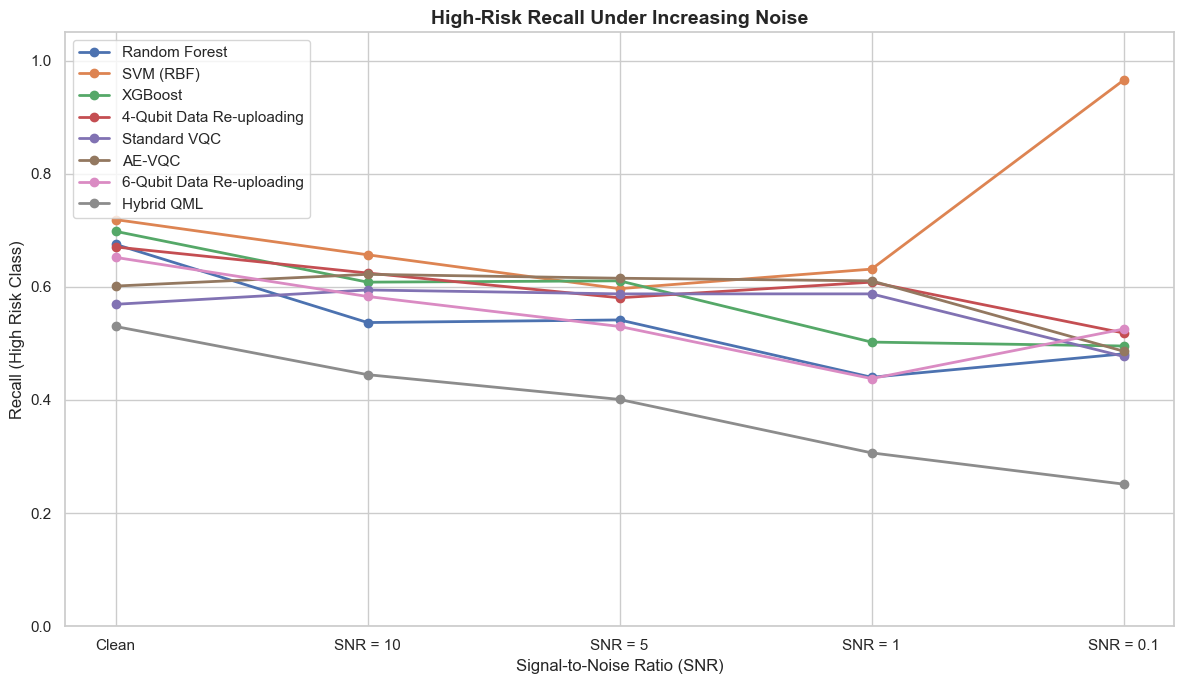

In [22]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import seaborn as sns


required_artifacts = (
    "trained_rf_model",
    "rf_scaler",
    "rf_X_test_raw",
    "rf_y_test",
    "trained_svm_model",
    "svm_scaler",
    "trained_xgb_model",
    "xgb_scaler",
    "trained_weights_data_reuploading_4q",
    "data_reuploading_4q_scaler",
    "data_reuploading_4q_pca",
    "data_reuploading_4q_angle_scaler",
    "trained_weights_standard_vqc",
    "standard_vqc_scaler",
    "standard_vqc_pca",
    "standard_vqc_angle_scaler",
    "trained_weights_old_quantum",
    "old_quantum_scaler",
    "old_quantum_pca",
    "old_quantum_angle_scaler",
    "trained_weights_data_reuploading_6q",
    "data_reuploading_6q_scaler",
    "data_reuploading_6q_pca",
    "data_reuploading_6q_angle_scaler",
    "trained_hybrid_model",
    "hybrid_scaler",
)
missing_artifacts = [name for name in required_artifacts if name not in globals()]
if missing_artifacts:
    raise RuntimeError(
        "Run the model-training cells first; preserved artifacts are missing: "
        + ", ".join(missing_artifacts)
    )


y_test_stress = rf_y_test
X_test_raw_stress = rf_X_test_raw
X_test_scaled_clean = rf_scaler.transform(X_test_raw_stress)

label_sets = (
    svm_y_test,
    xgb_y_test,
    data_reuploading_4q_y_test,
    standard_vqc_y_test,
    old_quantum_y_test,
    data_reuploading_6q_y_test,
    hybrid_y_test,
)
if any(not np.array_equal(labels, y_test_stress) for labels in label_sets):
    raise ValueError("The trained models do not share the same held-out test split.")

scalers = (
    svm_scaler,
    xgb_scaler,
    data_reuploading_4q_scaler,
    standard_vqc_scaler,
    old_quantum_scaler,
    data_reuploading_6q_scaler,
    hybrid_scaler,
)
if any(
    not np.allclose(scaler.transform(X_test_raw_stress), X_test_scaled_clean)
    for scaler in scalers
):
    raise ValueError("The trained models use different scaled test inputs.")


def _quantum_predictions(qnode, trained_quantum_parameters, X_scaled, pca, angle_scaler):
    X_encoded = angle_scaler.transform(pca.transform(X_scaled))
    global num_qubits, num_layers
    previous_num_qubits, previous_num_layers = num_qubits, num_layers
    try:
        num_qubits = X_encoded.shape[1]
        num_layers = trained_quantum_parameters.shape[0]
        scores = [float(qnode(trained_quantum_parameters, sample)) for sample in X_encoded]
    finally:
        num_qubits, num_layers = previous_num_qubits, previous_num_layers
    return (np.sign(scores) == 1).astype(int)


def _hybrid_predictions(X_scaled):
    device = next(trained_hybrid_model.parameters()).device
    X_tensor = torch.as_tensor(X_scaled, dtype=torch.float32, device=device)
    trained_hybrid_model.eval()
    with torch.no_grad():
        outputs = trained_hybrid_model(X_tensor)
    return (outputs.detach().cpu().numpy().ravel() >= 0.5).astype(int)


snr_levels = [float("inf"), 10, 5, 1, 0.1]
x_labels = ["Clean", "SNR = 10", "SNR = 5", "SNR = 1", "SNR = 0.1"]

results = {
    "Random Forest": [],
    "SVM (RBF)": [],
    "XGBoost": [],
    "4-Qubit Data Re-uploading": [],
    "Standard VQC": [],
    "AE-VQC": [],
    "6-Qubit Data Re-uploading": [],
    "Hybrid QML": [],
}

print("Starting noise stress testing on the preserved trained models...")
for snr in snr_levels:
    print(f"\nTesting SNR = {snr}")

    if np.isinf(snr):
        noise = np.zeros_like(X_test_scaled_clean)
    else:
        signal_power = np.mean(X_test_scaled_clean ** 2, axis=0)
        noise_variance = signal_power / snr
        noise = np.random.normal(
            0,
            np.sqrt(noise_variance),
            X_test_scaled_clean.shape,
        )

    rf_inputs = rf_scaler.transform(X_test_raw_stress) + noise
    svm_inputs = svm_scaler.transform(X_test_raw_stress) + noise
    xgb_inputs = xgb_scaler.transform(X_test_raw_stress) + noise
    reupload4_inputs = data_reuploading_4q_scaler.transform(X_test_raw_stress) + noise
    vqc_inputs = standard_vqc_scaler.transform(X_test_raw_stress) + noise
    old_quantum_inputs = old_quantum_scaler.transform(X_test_raw_stress) + noise
    reupload6_inputs = data_reuploading_6q_scaler.transform(X_test_raw_stress) + noise
    hybrid_inputs = hybrid_scaler.transform(X_test_raw_stress) + noise

    predictions = {
        "Random Forest": trained_rf_model.predict(rf_inputs),
        "SVM (RBF)": trained_svm_model.predict(svm_inputs),
        "XGBoost": trained_xgb_model.predict(xgb_inputs),
        "4-Qubit Data Re-uploading": _quantum_predictions(
            data_reuploading_classifier,
            trained_weights_data_reuploading_4q,
            reupload4_inputs,
            data_reuploading_4q_pca,
            data_reuploading_4q_angle_scaler,
        ),
        "Standard VQC": _quantum_predictions(
            vqc_classifier,
            trained_weights_standard_vqc,
            vqc_inputs,
            standard_vqc_pca,
            standard_vqc_angle_scaler,
        ),
        "AE-VQC": _quantum_predictions(
            quantum_classifier,
            trained_weights_old_quantum,
            old_quantum_inputs,
            old_quantum_pca,
            old_quantum_angle_scaler,
        ),
        "6-Qubit Data Re-uploading": _quantum_predictions(
            data_reuploading_6q,
            trained_weights_data_reuploading_6q,
            reupload6_inputs,
            data_reuploading_6q_pca,
            data_reuploading_6q_angle_scaler,
        ),
        "Hybrid QML": _hybrid_predictions(hybrid_inputs),
    }

    for model_name, pred in predictions.items():
        results[model_name].append(
            recall_score(y_test_stress, pred, pos_label=1, zero_division=0)
        )

print("\nStress testing completed.")

result_df = pd.DataFrame(results, index=x_labels)
print("\n================ STRESS TEST RESULTS ================")
print(result_df.round(4))

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
for model_name, scores in results.items():
    plt.plot(x_labels, scores, marker="o", linewidth=2, label=model_name)

plt.title("High-Risk Recall Under Increasing Noise", fontsize=14, weight="bold")
plt.xlabel("Signal-to-Noise Ratio (SNR)")
plt.ylabel("Recall (High Risk Class)")
plt.ylim(0, 1.05)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("all_models_snr_vs_high_risk_recall.png", dpi=300)
plt.show()


# Stress test - Accuracy

Starting noise stress testing on the preserved trained models...

Testing SNR = inf

Testing SNR = 10

Testing SNR = 5

Testing SNR = 1

Testing SNR = 0.1

Stress testing completed.

================ STRESS TEST RESULTS ================
           Random Forest  SVM (RBF)  XGBoost  4-Qubit Data Re-uploading  \
Clean             0.7439     0.7698   0.7584                     0.6953   
SNR = 10          0.7029     0.7143   0.7143                     0.6292   
SNR = 5           0.6695     0.6847   0.6626                     0.6026   
SNR = 1           0.6087     0.5479   0.6018                     0.5084   
SNR = 0.1         0.5380     0.3427   0.5334                     0.5312   

           Standard VQC  AE-VQC  6-Qubit Data Re-uploading  Hybrid QML  
Clean            0.7181  0.7059                     0.6900      0.8100  
SNR = 10         0.6778  0.6702                     0.6147      0.7188  
SNR = 5          0.6831  0.6740                     0.5760      0.6884  
SNR = 1          0.5

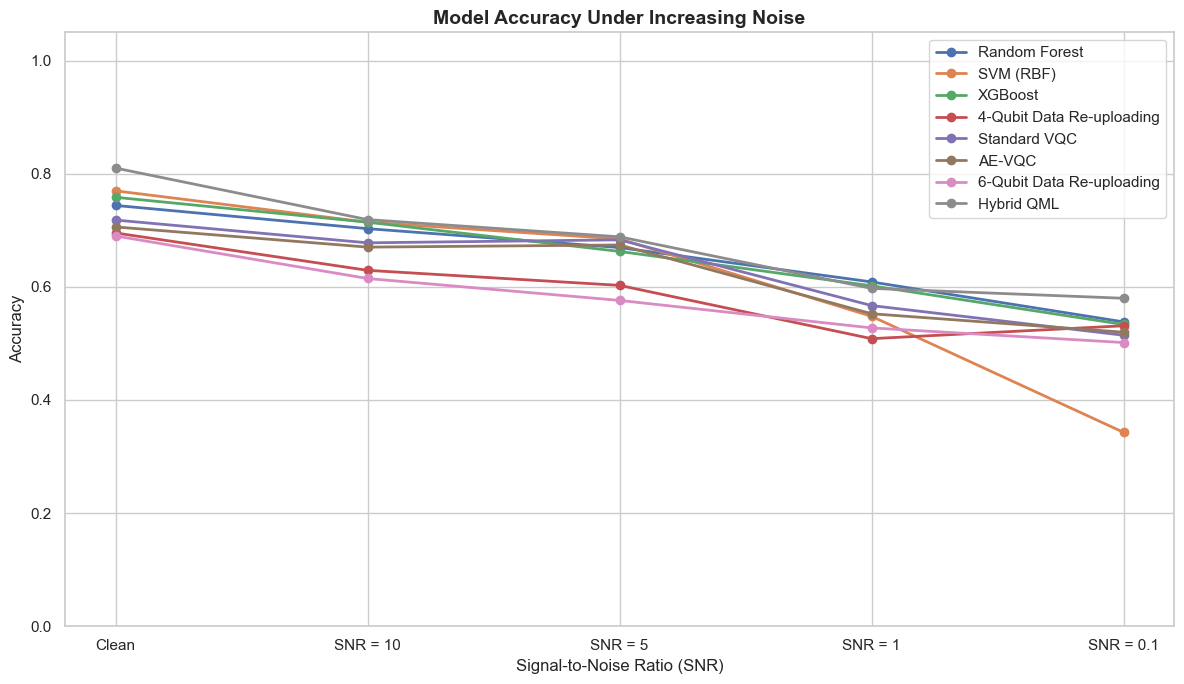

In [23]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


required_artifacts = (
    "trained_rf_model",
    "rf_scaler",
    "rf_X_test_raw",
    "rf_y_test",
    "trained_svm_model",
    "svm_scaler",
    "trained_xgb_model",
    "xgb_scaler",
    "trained_weights_data_reuploading_4q",
    "data_reuploading_4q_scaler",
    "data_reuploading_4q_pca",
    "data_reuploading_4q_angle_scaler",
    "trained_weights_standard_vqc",
    "standard_vqc_scaler",
    "standard_vqc_pca",
    "standard_vqc_angle_scaler",
    "trained_weights_old_quantum",
    "old_quantum_scaler",
    "old_quantum_pca",
    "old_quantum_angle_scaler",
    "trained_weights_data_reuploading_6q",
    "data_reuploading_6q_scaler",
    "data_reuploading_6q_pca",
    "data_reuploading_6q_angle_scaler",
    "trained_hybrid_model",
    "hybrid_scaler",
)
missing_artifacts = [name for name in required_artifacts if name not in globals()]
if missing_artifacts:
    raise RuntimeError(
        "Run the model-training cells first; preserved artifacts are missing: "
        + ", ".join(missing_artifacts)
    )


y_test_stress = rf_y_test
X_test_raw_stress = rf_X_test_raw
X_test_scaled_clean = rf_scaler.transform(X_test_raw_stress)

label_sets = (
    svm_y_test,
    xgb_y_test,
    data_reuploading_4q_y_test,
    standard_vqc_y_test,
    old_quantum_y_test,
    data_reuploading_6q_y_test,
    hybrid_y_test,
)
if any(not np.array_equal(labels, y_test_stress) for labels in label_sets):
    raise ValueError("The trained models do not share the same held-out test split.")

scalers = (
    svm_scaler,
    xgb_scaler,
    data_reuploading_4q_scaler,
    standard_vqc_scaler,
    old_quantum_scaler,
    data_reuploading_6q_scaler,
    hybrid_scaler,
)
if any(
    not np.allclose(scaler.transform(X_test_raw_stress), X_test_scaled_clean)
    for scaler in scalers
):
    raise ValueError("The trained models use different scaled test inputs.")


def _quantum_predictions(qnode, trained_quantum_parameters, X_scaled, pca, angle_scaler):
    X_encoded = angle_scaler.transform(pca.transform(X_scaled))
    global num_qubits, num_layers
    previous_num_qubits, previous_num_layers = num_qubits, num_layers
    try:
        num_qubits = X_encoded.shape[1]
        num_layers = trained_quantum_parameters.shape[0]
        scores = [float(qnode(trained_quantum_parameters, sample)) for sample in X_encoded]
    finally:
        num_qubits, num_layers = previous_num_qubits, previous_num_layers
    return (np.sign(scores) == 1).astype(int)


def _hybrid_predictions(X_scaled):
    device = next(trained_hybrid_model.parameters()).device
    X_tensor = torch.as_tensor(X_scaled, dtype=torch.float32, device=device)
    trained_hybrid_model.eval()
    with torch.no_grad():
        outputs = trained_hybrid_model(X_tensor)
    return (outputs.detach().cpu().numpy().ravel() >= 0.5).astype(int)


snr_levels = [float("inf"), 10, 5, 1, 0.1]
x_labels = ["Clean", "SNR = 10", "SNR = 5", "SNR = 1", "SNR = 0.1"]

results = {
    "Random Forest": [],
    "SVM (RBF)": [],
    "XGBoost": [],
    "4-Qubit Data Re-uploading": [],
    "Standard VQC": [],
    "AE-VQC": [],
    "6-Qubit Data Re-uploading": [],
    "Hybrid QML": [],
}

print("Starting noise stress testing on the preserved trained models...")
for snr in snr_levels:
    print(f"\nTesting SNR = {snr}")

    if np.isinf(snr):
        noise = np.zeros_like(X_test_scaled_clean)
    else:
        signal_power = np.mean(X_test_scaled_clean ** 2, axis=0)
        noise_variance = signal_power / snr
        noise = np.random.normal(
            0,
            np.sqrt(noise_variance),
            X_test_scaled_clean.shape,
        )

    rf_inputs = rf_scaler.transform(X_test_raw_stress) + noise
    svm_inputs = svm_scaler.transform(X_test_raw_stress) + noise
    xgb_inputs = xgb_scaler.transform(X_test_raw_stress) + noise
    reupload4_inputs = data_reuploading_4q_scaler.transform(X_test_raw_stress) + noise
    vqc_inputs = standard_vqc_scaler.transform(X_test_raw_stress) + noise
    old_quantum_inputs = old_quantum_scaler.transform(X_test_raw_stress) + noise
    reupload6_inputs = data_reuploading_6q_scaler.transform(X_test_raw_stress) + noise
    hybrid_inputs = hybrid_scaler.transform(X_test_raw_stress) + noise

    predictions = {
        "Random Forest": trained_rf_model.predict(rf_inputs),
        "SVM (RBF)": trained_svm_model.predict(svm_inputs),
        "XGBoost": trained_xgb_model.predict(xgb_inputs),
        "4-Qubit Data Re-uploading": _quantum_predictions(
            data_reuploading_classifier,
            trained_weights_data_reuploading_4q,
            reupload4_inputs,
            data_reuploading_4q_pca,
            data_reuploading_4q_angle_scaler,
        ),
        "Standard VQC": _quantum_predictions(
            vqc_classifier,
            trained_weights_standard_vqc,
            vqc_inputs,
            standard_vqc_pca,
            standard_vqc_angle_scaler,
        ),
        "AE-VQC": _quantum_predictions(
            quantum_classifier,
            trained_weights_old_quantum,
            old_quantum_inputs,
            old_quantum_pca,
            old_quantum_angle_scaler,
        ),
        "6-Qubit Data Re-uploading": _quantum_predictions(
            data_reuploading_6q,
            trained_weights_data_reuploading_6q,
            reupload6_inputs,
            data_reuploading_6q_pca,
            data_reuploading_6q_angle_scaler,
        ),
        "Hybrid QML": _hybrid_predictions(hybrid_inputs),
    }

    for model_name, pred in predictions.items():
        results[model_name].append(
            accuracy_score(y_test_stress, pred)
        )

print("\nStress testing completed.")

result_df = pd.DataFrame(results, index=x_labels)
print("\n================ STRESS TEST RESULTS ================")
print(result_df.round(4))

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
for model_name, scores in results.items():
    plt.plot(x_labels, scores, marker="o", linewidth=2, label=model_name)

plt.title("Model Accuracy Under Increasing Noise", fontsize=14, weight="bold")
plt.xlabel("Signal-to-Noise Ratio (SNR)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("all_models_snr_vs_accuracy.png", dpi=300)
plt.show()


## Coastal Erosion Risk Prediction Models

* **Random Forest (RF):** Combines predictions from many decision trees.
* **Support Vector Machine (SVM-RBF):** Uses a radial-basis kernel to classify nonlinear patterns.
* **Extreme Gradient Boosting (XGBoost):** Builds boosted trees, with each stage correcting earlier errors.
* **4-Qubit Data Re-uploading Quantum Classifier:** Repeatedly encodes PCA features in a trainable four-qubit circuit.
* **Standard Variational Quantum Classifier (VQC):** Encodes PCA features once, then applies trainable entangling layers.
* **Angle-Embedded Variational Quantum Classifier (AE-VQC):** Uses angle embedding followed by strongly entangling trainable quantum layers.
* **6-Qubit Data Re-uploading Quantum Classifier:** Repeatedly encodes PCA features in a trainable six-qubit circuit.
* **Hybrid Quantum-Classical Neural Network (Hybrid QML):** Combines classical PyTorch feature layers, a PennyLane quantum layer, and a classical classifier.



Training time and ROC-AUC results:


,Model,Training Time (seconds),ROC-AUC
0,Random Forest,0.3056,0.859776
1,SVM-RBF,0.6084,0.839590
2,XGBoost,0.0947,0.867390
3,4-Qubit Data Re-uploading,565.9380,0.770777
4,Standard VQC,1103.1403,0.742636
5,AE-VQC,1254.4029,0.747006
6,6-Qubit Data Re-uploading,1068.6162,0.743594
7,Hybrid QML,1387.0557,0.849256


C:\Users\prabh\AppData\Local\Temp\ipykernel_11612\2291928278.py:241: UserWarning: You passed a edgecolor/edgecolors ('#d62728') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\prabh\AppData\Local\Temp\ipykernel_11612\2291928278.py:241: UserWarning: You passed a edgecolor/edgecolors ('#9467bd') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\prabh\AppData\Local\Temp\ipykernel_11612\2291928278.py:241: UserWarning: You passed a edgecolor/edgecolors ('#8c564b') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\prabh\AppData\Local\Temp\ipykernel_11612\2291928278.py:241: UserWarning: You passed a edgecolor/edgecolors ('#e377c2') for an unfilled marker ('x').  Matplot

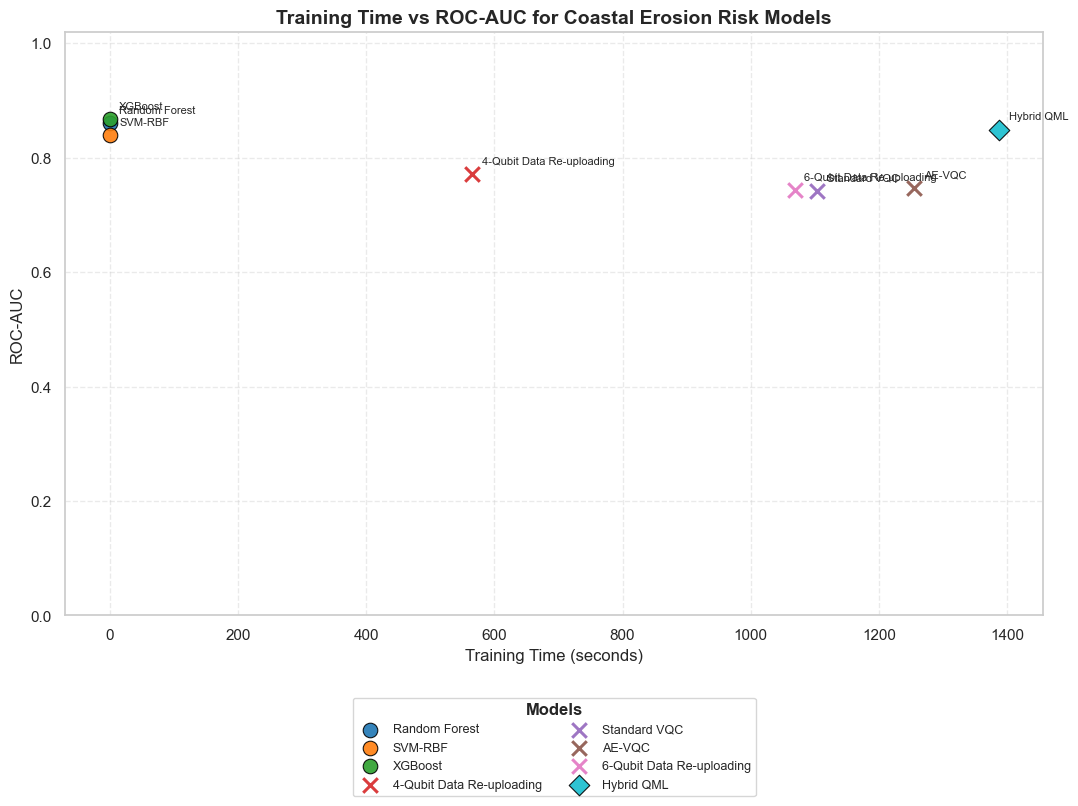

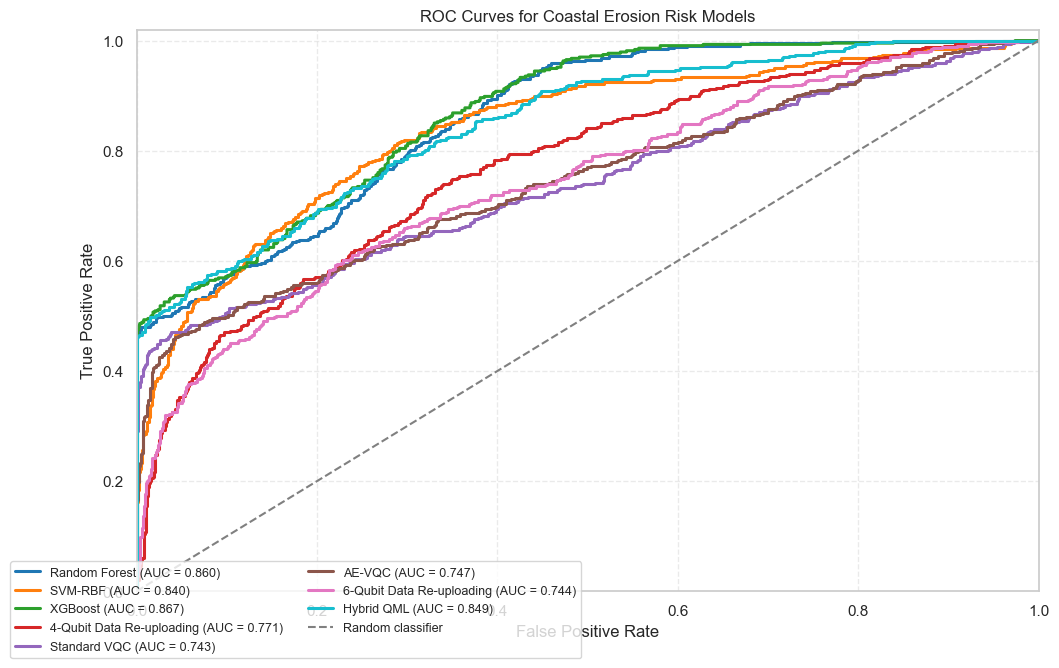

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Training times recovered from the saved output of each model's existing training cell.
# These are recorded measurements, not new estimates. Replace a value only if you
# have a more authoritative saved training-time result.
training_times = {
    "Random Forest": 0.3056,
    "SVM-RBF": 0.6084,
    "XGBoost": 0.0947,
    "4-Qubit Data Re-uploading": 565.9380,
    "Standard VQC": 1103.1403,
    "AE-VQC": 1254.4029,
    "6-Qubit Data Re-uploading": 1068.6162,
    "Hybrid QML": 1387.0557,
}

model_order = list(training_times)
artifact_requirements = {
    "Random Forest": ("trained_rf_model", "rf_scaler", "rf_X_test_raw", "rf_y_test"),
    "SVM-RBF": ("trained_svm_model", "svm_scaler", "svm_y_test"),
    "XGBoost": ("trained_xgb_model", "xgb_scaler", "xgb_y_test"),
    "4-Qubit Data Re-uploading": (
        "data_reuploading_classifier", "trained_weights_data_reuploading_4q",
        "data_reuploading_4q_scaler", "data_reuploading_4q_pca",
        "data_reuploading_4q_angle_scaler", "data_reuploading_4q_y_test",
    ),
    "Standard VQC": (
        "vqc_classifier", "trained_weights_standard_vqc", "standard_vqc_scaler",
        "standard_vqc_pca", "standard_vqc_angle_scaler", "standard_vqc_y_test",
    ),
    "AE-VQC": (
        "quantum_classifier", "trained_weights_old_quantum", "old_quantum_scaler",
        "old_quantum_pca", "old_quantum_angle_scaler", "old_quantum_y_test",
    ),
    "6-Qubit Data Re-uploading": (
        "data_reuploading_6q", "trained_weights_data_reuploading_6q",
        "data_reuploading_6q_scaler", "data_reuploading_6q_pca",
        "data_reuploading_6q_angle_scaler", "data_reuploading_6q_y_test",
    ),
    "Hybrid QML": (
        "trained_hybrid_model", "hybrid_scaler", "hybrid_y_test",
    ),
}

missing_by_model = {
    name: [artifact for artifact in artifacts if artifact not in globals()]
    for name, artifacts in artifact_requirements.items()
}
for name, missing in missing_by_model.items():
    if missing:
        print(f"Missing model information for {name}: {', '.join(missing)}")

if "rf_X_test_raw" not in globals() or "rf_y_test" not in globals():
    raise RuntimeError(
        "Cannot evaluate ROC-AUC: the preserved Random Forest test features/labels "
        "(rf_X_test_raw, rf_y_test) are unavailable. Run the existing training/evaluation "
        "cells that created the saved split; this cell will not create a new split."
    )

X_roc_raw = rf_X_test_raw
y_roc_true = np.asarray(rf_y_test)
if np.unique(y_roc_true).size != 2:
    raise ValueError("ROC-AUC requires both classes in the preserved test labels.")

# Each model uses its saved fitted preprocessing and its own test labels.
label_variable_by_model = {
    "SVM-RBF": "svm_y_test",
    "XGBoost": "xgb_y_test",
    "4-Qubit Data Re-uploading": "data_reuploading_4q_y_test",
    "Standard VQC": "standard_vqc_y_test",
    "AE-VQC": "old_quantum_y_test",
    "6-Qubit Data Re-uploading": "data_reuploading_6q_y_test",
    "Hybrid QML": "hybrid_y_test",
}
for name, variable_name in label_variable_by_model.items():
    if not missing_by_model[name] and not np.array_equal(globals()[variable_name], y_roc_true):
        raise ValueError(f"{name} does not use the same held-out test labels.")


def _continuous_quantum_scores(qnode, trained_parameters, X_scaled, pca, angle_scaler):
    """Return rescaled expectation values in [0, 1], without class thresholding."""
    encoded = angle_scaler.transform(pca.transform(X_scaled))
    global num_qubits, num_layers
    old_qubits, old_layers = num_qubits, num_layers
    try:
        num_qubits = encoded.shape[1]
        num_layers = trained_parameters.shape[0]
        expectation_scores = np.asarray(
            [float(qnode(trained_parameters, row)) for row in encoded],
            dtype=float,
        )
    finally:
        num_qubits, num_layers = old_qubits, old_layers
    return (expectation_scores + 1.0) / 2.0


continuous_scores = {}

if not missing_by_model["Random Forest"]:
    continuous_scores["Random Forest"] = trained_rf_model.predict_proba(
        rf_scaler.transform(X_roc_raw)
    )[:, 1]

if not missing_by_model["SVM-RBF"]:
    continuous_scores["SVM-RBF"] = trained_svm_model.decision_function(
        svm_scaler.transform(X_roc_raw)
    )

if not missing_by_model["XGBoost"]:
    continuous_scores["XGBoost"] = trained_xgb_model.predict_proba(
        xgb_scaler.transform(X_roc_raw)
    )[:, 1]

if not missing_by_model["4-Qubit Data Re-uploading"]:
    continuous_scores["4-Qubit Data Re-uploading"] = _continuous_quantum_scores(
        data_reuploading_classifier,
        trained_weights_data_reuploading_4q,
        data_reuploading_4q_scaler.transform(X_roc_raw),
        data_reuploading_4q_pca,
        data_reuploading_4q_angle_scaler,
    )

if not missing_by_model["Standard VQC"]:
    continuous_scores["Standard VQC"] = _continuous_quantum_scores(
        vqc_classifier,
        trained_weights_standard_vqc,
        standard_vqc_scaler.transform(X_roc_raw),
        standard_vqc_pca,
        standard_vqc_angle_scaler,
    )

if not missing_by_model["AE-VQC"]:
    continuous_scores["AE-VQC"] = _continuous_quantum_scores(
        quantum_classifier,
        trained_weights_old_quantum,
        old_quantum_scaler.transform(X_roc_raw),
        old_quantum_pca,
        old_quantum_angle_scaler,
    )

if not missing_by_model["6-Qubit Data Re-uploading"]:
    continuous_scores["6-Qubit Data Re-uploading"] = _continuous_quantum_scores(
        data_reuploading_6q,
        trained_weights_data_reuploading_6q,
        data_reuploading_6q_scaler.transform(X_roc_raw),
        data_reuploading_6q_pca,
        data_reuploading_6q_angle_scaler,
    )

if not missing_by_model["Hybrid QML"]:
    hybrid_device = next(trained_hybrid_model.parameters()).device
    hybrid_test_tensor = torch.as_tensor(
        hybrid_scaler.transform(X_roc_raw),
        dtype=torch.float32,
        device=hybrid_device,
    )
    trained_hybrid_model.eval()
    with torch.no_grad():
        continuous_scores["Hybrid QML"] = (
            trained_hybrid_model(hybrid_test_tensor).detach().cpu().numpy().ravel()
        )

roc_auc_values = {}
roc_curves = {}
for model_name in model_order:
    if model_name not in continuous_scores:
        continue
    scores = np.asarray(continuous_scores[model_name], dtype=float).ravel()
    if scores.shape[0] != y_roc_true.shape[0]:
        raise ValueError(f"{model_name} score count does not match the test labels.")
    if not np.all(np.isfinite(scores)):
        raise ValueError(f"{model_name} produced non-finite ROC scores.")
    roc_auc_values[model_name] = roc_auc_score(y_roc_true, scores)
    roc_curves[model_name] = roc_curve(y_roc_true, scores)

results_table = pd.DataFrame({
    "Model": model_order,
    "Training Time (seconds)": [training_times[name] for name in model_order],
    "ROC-AUC": [roc_auc_values.get(name, np.nan) for name in model_order],
})
print("\nTraining time and ROC-AUC results:")
display(results_table)

missing_times = [name for name, value in training_times.items() if value is None]
if missing_times:
    print(
        "Enter the previously measured training times in the training_times dictionary "
        "for: " + ", ".join(missing_times)
    )

# Scatter plot: one point for each model with both time and ROC-AUC available.
# Every model gets a different color
colors = {
    "Random Forest": "#1f77b4",
    "SVM-RBF": "#ff7f0e",
    "XGBoost": "#2ca02c",
    "4-Qubit Data Re-uploading": "#d62728",
    "Standard VQC": "#9467bd",
    "AE-VQC": "#8c564b",
    "6-Qubit Data Re-uploading": "#e377c2",
    "Hybrid QML": "#17becf",
}

# Marker represents model category
markers = {
    "Random Forest": "o",                    # Classical
    "SVM-RBF": "o",                          # Classical
    "XGBoost": "o",                          # Classical
    "4-Qubit Data Re-uploading": "x",       # Quantum
    "Standard VQC": "x",                     # Quantum
    "AE-VQC": "x",                           # Quantum
    "6-Qubit Data Re-uploading": "x",        # Quantum
    "Hybrid QML": "D",                       # Hybrid
} 

plot_table = results_table.dropna(subset=["Training Time (seconds)", "ROC-AUC"])
fig, ax = plt.subplots(figsize=(11, 8))
# ax.scatter(
#     plot_table["Training Time (seconds)"],
#     plot_table["ROC-AUC"],
#     s=85,
#     alpha=0.85,
#     edgecolor="black",
#     linewidth=0.6,
# )
# for _, row in plot_table.iterrows():
#     ax.annotate(
#         row["Model"],
#         (row["Training Time (seconds)"], row["ROC-AUC"]),
#         xytext=(6, 6),
#         textcoords="offset points",
#         fontsize=8,
#     )

for _, row in plot_table.iterrows():
    model_name = row["Model"]

    ax.scatter(
        row["Training Time (seconds)"],
        row["ROC-AUC"],
        s=110,
        color=colors[model_name],
        marker=markers[model_name],
        linewidth=2.2 if markers[model_name] == "x" else 0.8,
        edgecolor="black" if markers[model_name] != "x" else colors[model_name],
        alpha=0.9,
        label=model_name,
    )

    # Model name next to the point
    ax.annotate(
        model_name,
        (
            row["Training Time (seconds)"],
            row["ROC-AUC"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Training Time vs ROC-AUC for Coastal Erosion Risk Models", fontsize=14, fontweight="bold")
ax.set_xlabel("Training Time (seconds)")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.0, 1.02)
ax.grid(True, linestyle="--", alpha=0.4)

# Legend at the bottom
legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=True,
    fontsize=9,
    title="Models",
)

legend.get_title().set_fontweight("bold")

fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.savefig("training_time_vs_roc_auc.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC curves: continuous scores only; no class-label thresholding is used.
fig, ax = plt.subplots(figsize=(11, 8))
for model_name, (false_positive_rate, true_positive_rate, _) in roc_curves.items():
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        color=colors[model_name],
        linewidth=2.2,
        label=f"{model_name} (AUC = {roc_auc_values[model_name]:.3f})",
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random classifier")
ax.set_title("ROC Curves for Coastal Erosion Risk Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.02)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="lower right", bbox_to_anchor=(0.5, -0.13), ncol=2, frameon=True, fontsize=9,)
fig.tight_layout()
fig.subplots_adjust(bottom=0.25)
fig.savefig("all_models_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

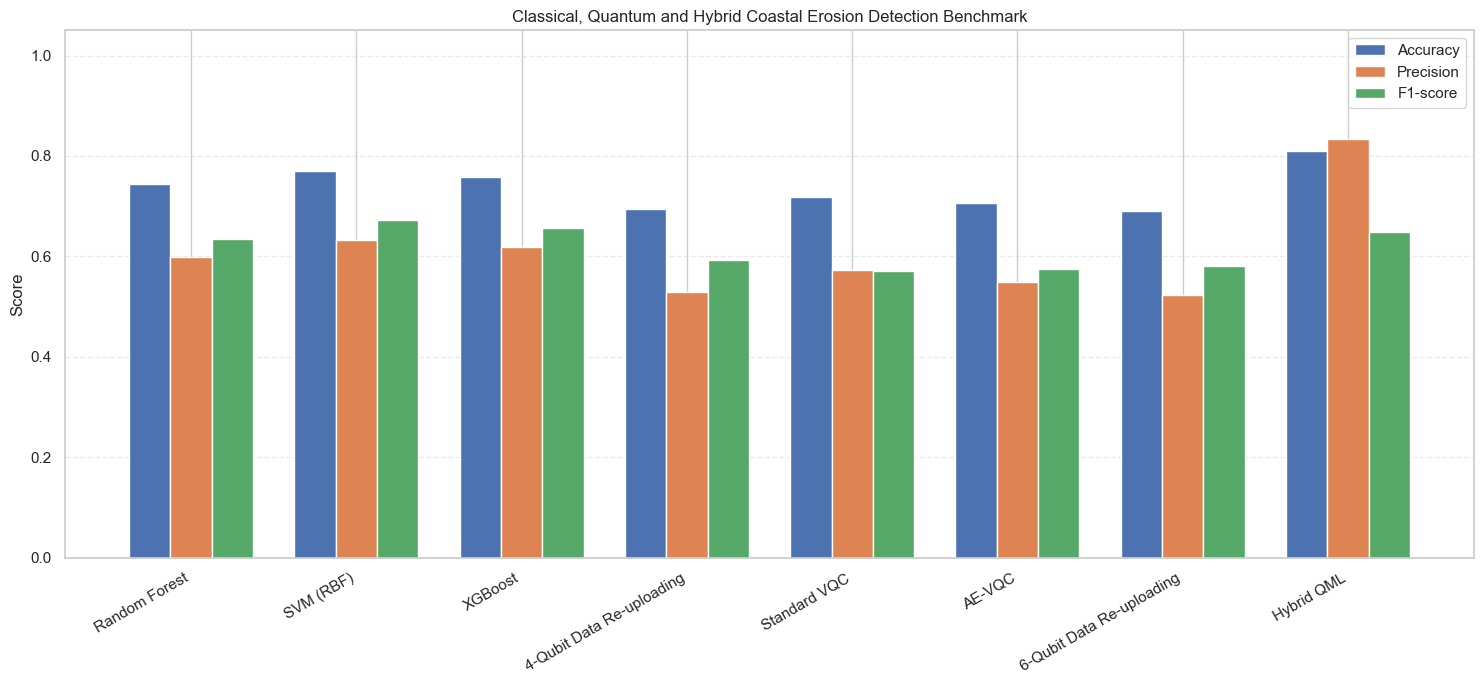

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, f1_score

# Compare the preserved models on their shared clean held-out test split.
y_true_metrics = rf_y_test
X_raw_metrics = rf_X_test_raw
predictions_metrics = {
    "Random Forest": trained_rf_model.predict(rf_scaler.transform(X_raw_metrics)),
    "SVM (RBF)": trained_svm_model.predict(svm_scaler.transform(X_raw_metrics)),
    "XGBoost": trained_xgb_model.predict(xgb_scaler.transform(X_raw_metrics)),
    "4-Qubit Data Re-uploading": _quantum_predictions(
        data_reuploading_classifier, trained_weights_data_reuploading_4q,
        data_reuploading_4q_scaler.transform(X_raw_metrics),
        data_reuploading_4q_pca, data_reuploading_4q_angle_scaler,
    ),
    "Standard VQC": _quantum_predictions(
        vqc_classifier, trained_weights_standard_vqc,
        standard_vqc_scaler.transform(X_raw_metrics),
        standard_vqc_pca, standard_vqc_angle_scaler,
    ),
    "AE-VQC": _quantum_predictions(
        quantum_classifier, trained_weights_old_quantum,
        old_quantum_scaler.transform(X_raw_metrics),
        old_quantum_pca, old_quantum_angle_scaler,
    ),
    "6-Qubit Data Re-uploading": _quantum_predictions(
        data_reuploading_6q, trained_weights_data_reuploading_6q,
        data_reuploading_6q_scaler.transform(X_raw_metrics),
        data_reuploading_6q_pca, data_reuploading_6q_angle_scaler,
    ),
    "Hybrid QML": _hybrid_predictions(hybrid_scaler.transform(X_raw_metrics)),
}

metric_names = ["Accuracy", "Precision", "F1-score"]
metric_functions = [accuracy_score, precision_score, f1_score]
model_names = list(predictions_metrics)
metric_values = {
    name: [
        function(y_true_metrics, predictions_metrics[model], **(
            {"zero_division": 0} if function is not accuracy_score else {}
        ))
        for model in model_names
    ]
    for name, function in zip(metric_names, metric_functions)
}

x = np.arange(len(model_names))
bar_width = 0.25
fig, ax = plt.subplots(figsize=(15, 7))
for index, metric_name in enumerate(metric_names):
    offset = (index - 1) * bar_width
    ax.bar(x + offset, metric_values[metric_name], bar_width, label=metric_name)

ax.set_title("Classical, Quantum and Hybrid Coastal Erosion Detection Benchmark")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
fig.savefig("all_models_accuracy_precision_f1.png", dpi=300, bbox_inches="tight")
plt.show()


# Final Unlabeled Prediction and Validation Pipeline

--- Starting Unlabeled Prediction & Validation Pipeline ---
Loaded dataset with shape: (5478, 12)
Predictions saved to 'coastal_erosion_predictions.csv' in 0.9455 seconds.

Prediction counts:
predicted_erosion_risk
Low/Moderate Risk    3519
High Risk            1959
Name: count, dtype: int64

--- Running Validation Testing Suite ---
Validation Accuracy:  0.8280
Validation Precision: 0.7228
Validation Recall:    0.7802
Validation F1-Score:  0.7504

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.89      0.85      0.87      3663
   High Risk       0.72      0.78      0.75      1815

    accuracy                           0.83      5478
   macro avg       0.80      0.82      0.81      5478
weighted avg       0.83      0.83      0.83      5478



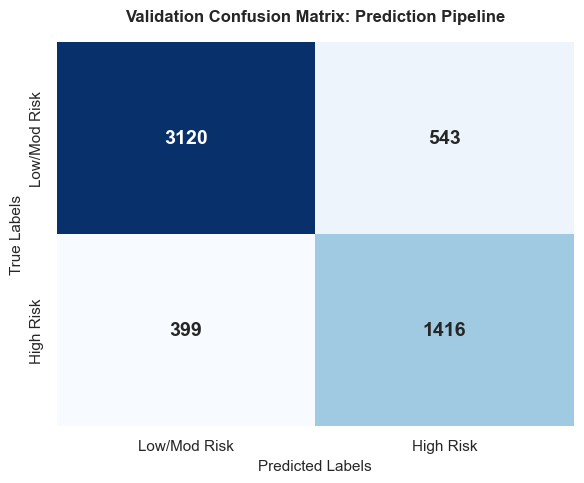

In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

def run_unlabeled_prediction_and_validation(
    model,
    scaler,
    unlabeled_csv_path='dataset_2026-2030.csv',
    output_csv_path='coastal_erosion_predictions.csv',
    true_labels_csv=None
):
    print("--- Starting Unlabeled Prediction & Validation Pipeline ---")
    start_time = time.perf_counter()

    df_new = pd.read_csv(unlabeled_csv_path)
    print(f"Loaded dataset with shape: {df_new.shape}")

    feature_cols = [
        'wave_height', 'wave_period', 'wave_direction',
        'precipitation', 'wind_speed', 'tidal_height_m'
    ]

    for col in feature_cols:
        if col not in df_new.columns:
            raise ValueError(f"Missing required feature column: {col}")

    X_raw = df_new[feature_cols].values
    X_scaled = scaler.transform(X_raw)

    pred_numeric = model.predict(X_scaled)

    risk_mapping = {0: 'Low/Moderate Risk', 1: 'High Risk'}
    df_new['predicted_erosion_risk'] = [
        risk_mapping.get(int(p), str(p)) for p in pred_numeric
    ]

    df_new.to_csv(output_csv_path, index=False)

    elapsed_time = time.perf_counter() - start_time
    print(f"Predictions saved to '{output_csv_path}' in {elapsed_time:.4f} seconds.")
    print("\nPrediction counts:")
    print(df_new['predicted_erosion_risk'].value_counts())

    if true_labels_csv:
        print("\n--- Running Validation Testing Suite ---")
        df_true = pd.read_csv(true_labels_csv)

        if 'erosion_risk' not in df_true.columns:
            print("Warning: 'erosion_risk' column not found. Skipping validation.")
            return

        y_true = df_true['erosion_risk'].apply(lambda x: 1 if x == 'High' else 0).values
        y_pred = pred_numeric

        if len(y_true) != len(y_pred):
            raise ValueError("Number of true labels does not match number of predictions.")

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        print(f"Validation Accuracy:  {acc:.4f}")
        print(f"Validation Precision: {prec:.4f}")
        print(f"Validation Recall:    {rec:.4f}")
        print(f"Validation F1-Score:  {f1:.4f}")
        print("\nDetailed Classification Report:")
        print(classification_report(
            y_true, y_pred,
            target_names=['Low/Mod Risk', 'High Risk']
        ))

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        sns.set_theme(style="white")
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['Low/Mod Risk', 'High Risk'],
            yticklabels=['Low/Mod Risk', 'High Risk'],
            annot_kws={"size": 14, "weight": "bold"}
        )
        plt.title(
            'Validation Confusion Matrix: Prediction Pipeline',
            fontsize=12,
            pad=15,
            weight='bold'
        )
        plt.xlabel('Predicted Labels', fontsize=11)
        plt.ylabel('True Labels', fontsize=11)
        plt.tight_layout()
        plt.savefig('validation_confusion_matrix.png', dpi=300)
        plt.show()

run_unlabeled_prediction_and_validation(
    model=trained_svm_model,
    scaler=svm_scaler,
    unlabeled_csv_path='dataset_2026-2030.csv',
    output_csv_path='coastal_erosion_predictions.csv',
    true_labels_csv='dataset_2026-2030.csv'
)